## 1. 🎯 Máquinas de Vetores de Suporte (SVM) - Guia Completo

### **O que são Vetores de Suporte? (A Base)**

**Analogia Simples:** Imagine que você é um árbitro separando dois times de futebol em um campo.

- **Objetivo:** Desenhar uma linha para separar o Time A do Time B
- **Vetores de Suporte:** Os jogadores mais próximos da sua linha de separação
- **Esses jogadores "sustentam" a decisão** sobre onde desenhar a linha

### **Por que Esses Jogadores Específicos Importam:**
- **Apenas os jogadores mais próximos influenciam o limite** - jogadores distantes não importam
- **Mova um vetor de suporte** → limite muda
- **Mova um jogador distante** → limite permanece o mesmo
- **Por isso SVM é "esparso"** - apenas alguns pontos de dados importam

### **Margem Rígida vs Suave (Duas Regras Diferentes):**

**Margem Rígida (Árbitro Rigoroso):**
- **Regra:** Separação perfeita exigida, ZERO violações
- **Prós:** Separação clara e limpa quando possível
- **Contras:** Falha se os dados não são perfeitamente separáveis (mundo real = bagunçado!)
- **Exemplo:** Separando jogadores profissionais vs amadores (diferença clara)

**Margem Suave (Árbitro Flexível):**
- **Regra:** Alguns jogadores podem cruzar a linha (violações permitidas com penalidade)
- **Parâmetro de Penalidade (C):** Controla quanta violação é permitida
  - **C Alto:** Rigoroso (poucas violações, limite complexo)
  - **C Baixo:** Relaxado (mais violações, limite simples)
- **Exemplo:** Separando jogadores bons vs ruins (alguma sobreposição esperada)

### **O Parâmetro ξ (Xi) - Medida de Violação:**
- **ξᵢ = 0:** Ponto é corretamente classificado fora da margem
- **0 < ξᵢ < 1:** Ponto é corretamente classificado mas dentro da margem  
- **ξᵢ ≥ 1:** Ponto é incorretamente classificado
- **Todos os pontos com ξᵢ > 0 são vetores de suporte!**

### **Aplicações do Mundo Real:**
- **Detecção de Spam em Email:** Separar spam de emails legítimos
- **Diagnóstico Médico:** Separar pacientes doentes de saudáveis
- **Reconhecimento de Imagem:** Separar gatos de cachorros em fotos
- **Financeiro:** Separar bons de maus candidatos a empréstimo

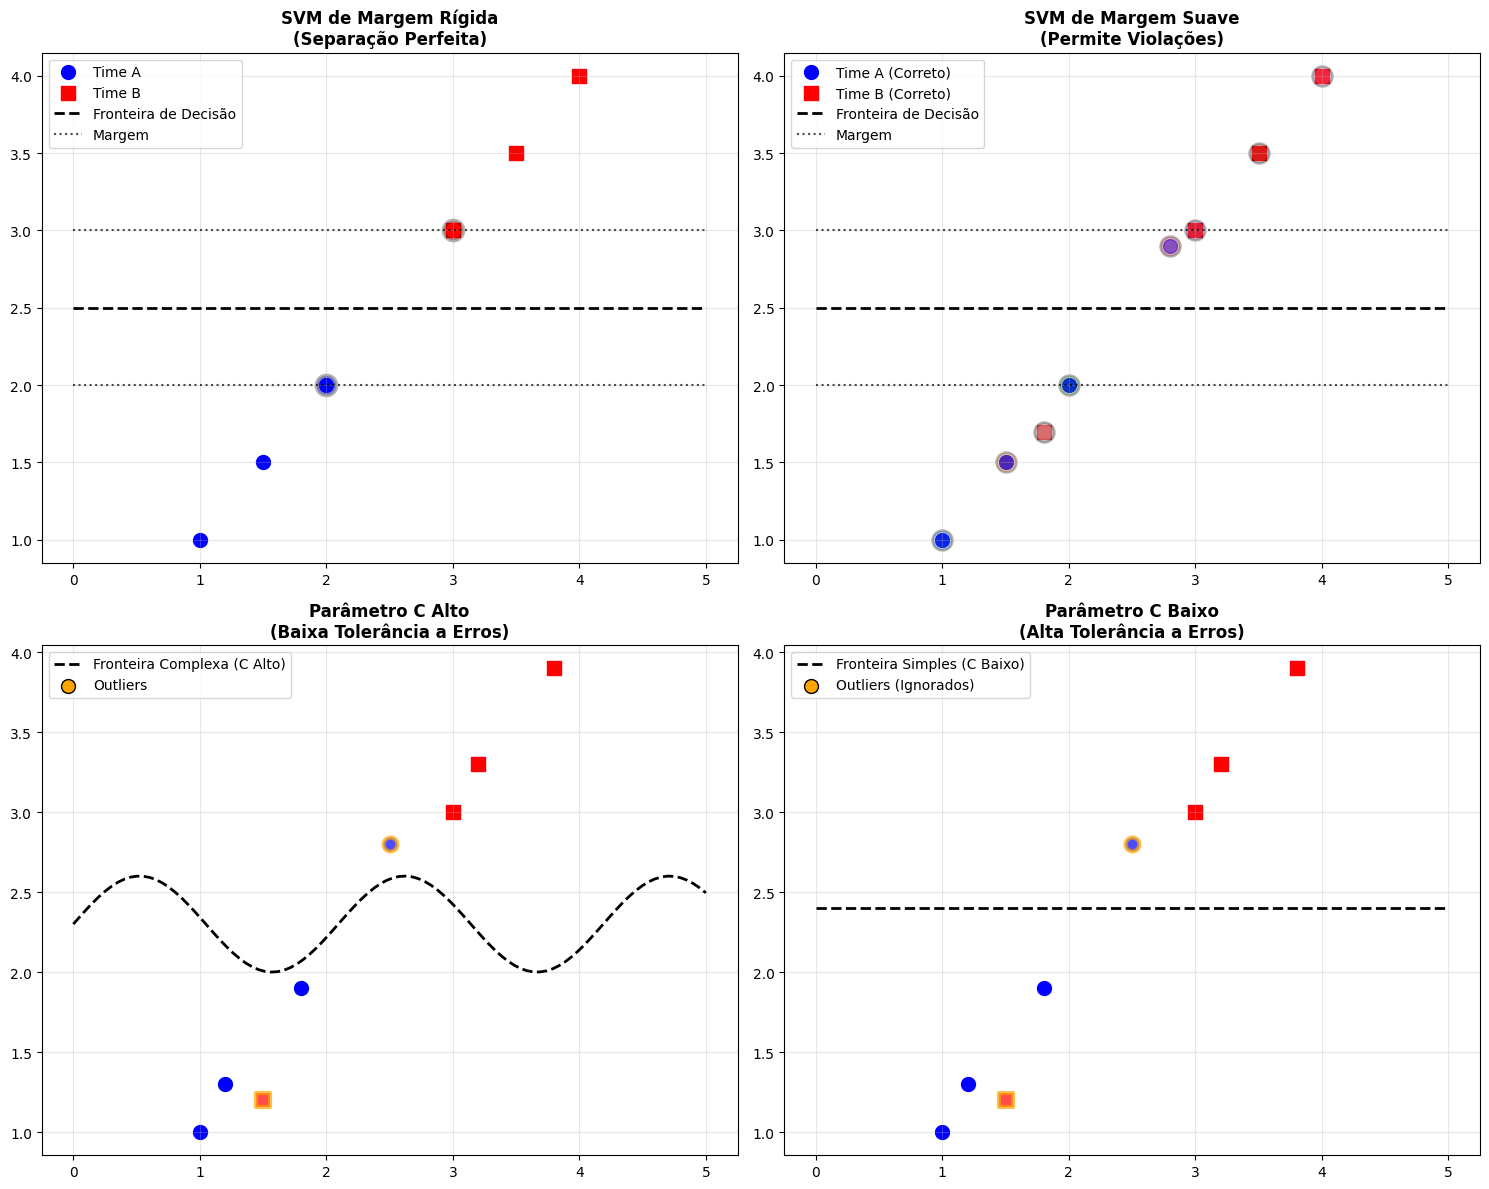

🔍 Principais Insights das Visualizações:
📊 Superior Esquerdo (Margem Rígida):
• Separação perfeita possível
• Apenas pontos na margem são vetores de suporte
• Limpo, mas frágil a novos dados

📊 Superior Direito (Margem Suave):
• Algumas violações permitidas
• Vetores de suporte incluem violadores
• Mais robusto à bagunça do mundo real

📊 Inferior Esquerdo (C Alto):
• Tenta classificar cada ponto corretamente
• Fronteira de decisão complexa e ondulada
• Risco de overfitting

📊 Inferior Direito (C Baixo):
• Aceita algumas classificações incorretas
• Fronteira de decisão simples e suave
• Melhor generalização

💡 Regras dos Vetores de Suporte:
• Qualquer ponto NA fronteira da margem → Vetor de Suporte
• Qualquer ponto VIOLANDO a margem → Vetor de Suporte
• Qualquer ponto LONGE da fronteira → NÃO é Vetor de Suporte
• Os vetores de suporte determinam todo o modelo!

🎯 Quiz de Identificação de Vetores de Suporte:
Análise da Distância da Fronteira de Decisão:
(Negativo = lado do Time A, Positi

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Visualização aprimorada de SVM com múltiplos exemplos
def visualize_svm_concept():
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    
    # Exemplo 1: Separação Perfeita (Margem Rígida)
    team_a_x = [1, 1.5, 2]
    team_a_y = [1, 1.5, 2]
    team_b_x = [3, 3.5, 4]
    team_b_y = [3, 3.5, 4]
    
    ax1.scatter(team_a_x, team_a_y, color='blue', s=100, label='Time A', marker='o')
    ax1.scatter(team_b_x, team_b_y, color='red', s=100, label='Time B', marker='s')
    ax1.plot([0, 5], [2.5, 2.5], 'k--', linewidth=2, label='Fronteira de Decisão')
    ax1.plot([0, 5], [2, 2], 'k:', alpha=0.7, label='Margem')
    ax1.plot([0, 5], [3, 3], 'k:', alpha=0.7)
    ax1.scatter([2], [2], color='blue', s=200, alpha=0.3, edgecolor='black', linewidth=3)
    ax1.scatter([3], [3], color='red', s=200, alpha=0.3, edgecolor='black', linewidth=3)
    ax1.set_title('SVM de Margem Rígida\n(Separação Perfeita)', fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Exemplo 2: Dados Sobrepostos (Margem Suave)
    np.random.seed(42)
    team_a_x2 = [1, 1.5, 2, 2.8]  # Um jogador cruza a linha
    team_a_y2 = [1, 1.5, 2, 2.9]
    team_b_x2 = [3, 3.5, 4, 1.8]  # Um jogador cruza a linha
    team_b_y2 = [3, 3.5, 4, 1.7]
    
    ax2.scatter(team_a_x2[:3], team_a_y2[:3], color='blue', s=100, label='Time A (Correto)', marker='o')
    ax2.scatter([team_a_x2[3]], [team_a_y2[3]], color='blue', s=100, marker='o', alpha=0.6)
    ax2.scatter(team_b_x2[:3], team_b_y2[:3], color='red', s=100, label='Time B (Correto)', marker='s')
    ax2.scatter([team_b_x2[3]], [team_b_y2[3]], color='red', s=100, marker='s', alpha=0.6)
    ax2.plot([0, 5], [2.5, 2.5], 'k--', linewidth=2, label='Fronteira de Decisão')
    ax2.plot([0, 5], [2, 2], 'k:', alpha=0.7, label='Margem')
    ax2.plot([0, 5], [3, 3], 'k:', alpha=0.7)
    # Highlight support vectors (including violators)
    for i in range(len(team_a_x2)):
        ax2.scatter([team_a_x2[i]], [team_a_y2[i]], s=200, alpha=0.3, edgecolor='black', linewidth=2)
    for i in range(len(team_b_x2)):
        ax2.scatter([team_b_x2[i]], [team_b_y2[i]], s=200, alpha=0.3, edgecolor='black', linewidth=2)
    ax2.set_title('SVM de Margem Suave\n(Permite Violações)', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Exemplo 3: Efeito do Parâmetro C - C Alto (Rigoroso)
    ax3.scatter([1, 1.2, 1.8], [1, 1.3, 1.9], color='blue', s=100, marker='o')
    ax3.scatter([3, 3.2, 3.8], [3, 3.3, 3.9], color='red', s=100, marker='s')
    # Outliers
    ax3.scatter([2.5], [2.8], color='blue', s=100, marker='o', alpha=0.7, edgecolor='orange', linewidth=3)
    ax3.scatter([1.5], [1.2], color='red', s=100, marker='s', alpha=0.7, edgecolor='orange', linewidth=3)
    # Fronteira complexa (C alto tenta classificar outliers corretamente)
    x_complex = np.linspace(0, 5, 100)
    y_complex = 2.3 + 0.3*np.sin(3*x_complex)  # Fronteira ondulada
    ax3.plot(x_complex, y_complex, 'k--', linewidth=2, label='Fronteira Complexa (C Alto)')
    ax3.set_title('Parâmetro C Alto\n(Baixa Tolerância a Erros)', fontsize=12, fontweight='bold')
    ax3.scatter([], [], color='orange', s=100, marker='o', label='Outliers', edgecolor='black')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Exemplo 4: Efeito do Parâmetro C - C Baixo (Relaxado)
    ax4.scatter([1, 1.2, 1.8], [1, 1.3, 1.9], color='blue', s=100, marker='o')
    ax4.scatter([3, 3.2, 3.8], [3, 3.3, 3.9], color='red', s=100, marker='s')
    # Mesmos outliers
    ax4.scatter([2.5], [2.8], color='blue', s=100, marker='o', alpha=0.7, edgecolor='orange', linewidth=3)
    ax4.scatter([1.5], [1.2], color='red', s=100, marker='s', alpha=0.7, edgecolor='orange', linewidth=3)
    # Fronteira simples (C baixo ignora alguns outliers)
    ax4.plot([0, 5], [2.4, 2.4], 'k--', linewidth=2, label='Fronteira Simples (C Baixo)')
    ax4.set_title('Parâmetro C Baixo\n(Alta Tolerância a Erros)', fontsize=12, fontweight='bold')
    ax4.scatter([], [], color='orange', s=100, marker='o', label='Outliers (Ignorados)', edgecolor='black')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("🔍 Principais Insights das Visualizações:")
    print("=" * 50)
    print("📊 Superior Esquerdo (Margem Rígida):")
    print("• Separação perfeita possível")
    print("• Apenas pontos na margem são vetores de suporte")
    print("• Limpo, mas frágil a novos dados")
    
    print("\n📊 Superior Direito (Margem Suave):")
    print("• Algumas violações permitidas")
    print("• Vetores de suporte incluem violadores")
    print("• Mais robusto à bagunça do mundo real")
    
    print("\n📊 Inferior Esquerdo (C Alto):")
    print("• Tenta classificar cada ponto corretamente")
    print("• Fronteira de decisão complexa e ondulada")
    print("• Risco de overfitting")
    
    print("\n📊 Inferior Direito (C Baixo):")
    print("• Aceita algumas classificações incorretas")
    print("• Fronteira de decisão simples e suave")
    print("• Melhor generalização")
    
    print("\n💡 Regras dos Vetores de Suporte:")
    print("• Qualquer ponto NA fronteira da margem → Vetor de Suporte")
    print("• Qualquer ponto VIOLANDO a margem → Vetor de Suporte")
    print("• Qualquer ponto LONGE da fronteira → NÃO é Vetor de Suporte")
    print("• Os vetores de suporte determinam todo o modelo!")

# Demonstração adicional: identificação de vetores de suporte
def identify_support_vectors():
    print("\n🎯 Quiz de Identificação de Vetores de Suporte:")
    print("=" * 45)
    
    # Dados de pontos de amostra com suas distâncias da fronteira de decisão
    points_data = [
        ("Ponto A", -2.0, "Longe da fronteira, lado do Time A"),
        ("Ponto B", -0.5, "Na fronteira da margem, lado do Time A"),
        ("Ponto C", 0.3, "Viola a margem, lado do Time B"),
        ("Ponto D", 1.5, "Longe da fronteira, lado do Time B"),
        ("Ponto E", 0.0, "Exatamente na fronteira de decisão"),
        ("Ponto F", -0.8, "Dentro da margem, lado do Time A"),
    ]
    
    print("Análise da Distância da Fronteira de Decisão:")
    print("(Negativo = lado do Time A, Positivo = lado do Time B)")
    print("-" * 50)
    
    support_vectors = []
    for name, distance, description in points_data:
        is_support = False
        explanation = ""
        
        if abs(distance) <= 0.5:  # Dentro da margem ou violando
            is_support = True
            if distance == 0:
                explanation = "NA fronteira de decisão"
            elif abs(distance) == 0.5:
                explanation = "NA fronteira da margem"
            else:
                explanation = "VIOLA a margem (dentro)"
        else:
            explanation = "FORA da margem (zona segura)"
        
        status = "✅ VETOR DE SUPORTE" if is_support else "❌ Não é vetor de suporte"
        print(f"{name}: {distance:+4.1f} | {description}")
        print(f"      → {explanation}")
        print(f"      → {status}")
        print()
        
        if is_support:
            support_vectors.append(name)
    
    print(f"🏆 Vetores de Suporte Finais: {', '.join(support_vectors)}")
    print(f"📊 Total: {len(support_vectors)} de {len(points_data)} pontos")

visualize_svm_concept()
identify_support_vectors()


---
## 2. 📊 Pontuação F1 - Guia Completo para Performance Equilibrada

### **O Problema: Por que Acurácia Não é Suficiente**

**Cenário:** Detectando doença rara (1% da população a tem)
- **Algoritmo Preguiçoso:** Sempre prever "Sem doença" 
- **Acurácia:** 99% (parece ótimo!)
- **Problema:** Perde TODOS os pacientes doentes! 

Por isso precisamos de **Precisão** e **Revocação**!

### **Compreendendo Através de Múltiplas Analogias:**

#### **🎓 Exemplo de Predição de Prova Escolar:**
**Contexto:** Prevendo quais estudantes passarão em um exame

**Precisão:** "Quando eu prevo que alguém vai passar, com que frequência estou certo?"
- Eu previ que 10 estudantes passariam
- 8 realmente passaram  
- Precisão = 8/10 = 80%
- **Tradução:** 80% das minhas predições de "aprovar" estavam corretas

**Revocação (Sensibilidade):** "De todos os estudantes que realmente passaram, quantos eu peguei?"
- 12 estudantes realmente passaram
- Eu previ 8 deles corretamente
- Revocação = 8/12 = 67%
- **Tradução:** Eu peguei 67% de todos os estudantes que passaram

#### **🏥 Exemplo de Diagnóstico Médico:**
**Contexto:** Teste de triagem para câncer

**Alta Precisão (95%):** 
- Quando o teste diz "câncer", geralmente está certo
- **Bom:** Poucos alarmes falsos, menos ansiedade do paciente
- **Ruim:** Pode perder alguns casos

**Alta Revocação (95%):**
- Captura a maioria dos casos de câncer
- **Bom:** Não perde pacientes doentes
- **Ruim:** Muitos alarmes falsos, tratamentos desnecessários

#### **🔍 Detecção de Spam em Email:**
**Precisão:** Dos emails que marquei como spam, quantos eram realmente spam?
**Revocação:** De todos os emails de spam, quantos eu peguei?

### **O Dilema do Trade-off:**
- **Limiar rigoroso:** Alta Precisão, Baixa Revocação (poucos alarmes falsos, mas perde casos reais)
- **Limiar frouxo:** Baixa Precisão, Alta Revocação (pega tudo, mas muitos alarmes falsos)
- **Pontuação F1:** Encontra o equilíbrio!

### **Fórmula da Pontuação F1 Explicada:**
**F1 = 2 × (Precisão × Revocação) / (Precisão + Revocação)**

**Por que Média Harmônica?**
- **Média aritmética:** (80% + 60%) / 2 = 70%
- **Média harmônica:** 2×(80%×60%)/(80%+60%) = 68.6%
- **Média harmônica pune desequilíbrio extremo**
- Se Precisão OU Revocação for muito baixa, F1 será baixo

### **Referências da Pontuação F1 do Mundo Real:**
- **F1 > 0.9:** Desempenho excelente 
- **F1 = 0.7-0.9:** Bom desempenho
- **F1 = 0.5-0.7:** Desempenho moderado  
- **F1 < 0.5:** Desempenho ruim (pior que adivinhação aleatória)

### **Quando Usar F1 vs Outras Métricas:**
- **Use F1 quando:** Classes são desequilibradas, tanto falsos positivos quanto falsos negativos são custosos
- **Use Precisão quando:** Falsos positivos são muito caros (ex: recomendações cirúrgicas)
- **Use Revocação quando:** Falsos negativos são muito caros (ex: triagem de doenças)
- **Use Acurácia quando:** Classes são equilibradas e todos os erros têm custo igual

In [2]:
# Calculadora aprimorada de Pontuação F1 com múltiplos cenários
def calculate_f1_interactive():
    print("📝 Calculadora de Pontuação F1 - Múltiplos Exemplos do Mundo Real")
    print("=" * 60)
    
    scenarios = [
        {
            "name": "Predição de Prova Escolar",
            "TP": 8, "FP": 2, "FN": 4, "TN": 16,
            "description": "Prevendo quais estudantes passam em um exame"
        },
        {
            "name": "Triagem de Câncer (Conservadora)",
            "TP": 18, "FP": 3, "FN": 2, "TN": 77, 
            "description": "Teste conservador - poucos alarmes falsos"
        },
        {
            "name": "Triagem de Câncer (Agressiva)",
            "TP": 19, "FP": 15, "FN": 1, "TN": 65,
            "description": "Teste agressivo - pega quase tudo"
        },
        {
            "name": "Detecção de Spam em Email",
            "TP": 85, "FP": 10, "FN": 15, "TN": 890,
            "description": "Filtrando spam de emails legítimos"
        }
    ]
    
    for i, scenario in enumerate(scenarios, 1):
        print(f"\n📊 CENÁRIO {i}: {scenario['name']}")
        print(f"Contexto: {scenario['description']}")
        print("-" * 50)
        
        TP, FP, FN, TN = scenario['TP'], scenario['FP'], scenario['FN'], scenario['TN']
        total = TP + FP + FN + TN
        
        # Calcular todas as métricas
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        accuracy = (TP + TN) / total
        specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
        
        # Exibir matriz de confusão
        print(f"Matriz de Confusão:")
        print(f"                 Previsto")
        print(f"              Positivo  Negativo")
        print(f"Real     Pos    {TP:3d}      {FN:3d}")
        print(f"         Neg    {FP:3d}      {TN:3d}")
        print()
        
        # Exibir métricas com interpretações
        print(f"📈 DETALHAMENTO DAS MÉTRICAS:")
        print(f"🎯 Acurácia:    {accuracy:.3f} ({accuracy*100:.1f}%) - Corretude geral")
        print(f"🎯 Precisão:   {precision:.3f} ({precision*100:.1f}%) - Das predições positivas, quantas corretas?")
        print(f"🎯 Revocação:    {recall:.3f} ({recall*100:.1f}%) - Dos positivos reais, quantos capturados?")
        print(f"🎯 Especificid.: {specificity:.3f} ({specificity*100:.1f}%) - Dos negativos reais, quantos corretos?")
        print(f"🏆 Pontuação F1:  {f1_score:.3f} ({f1_score*100:.1f}%) - Performance equilibrada")
        
        # Interpretation
        print(f"\n💡 INTERPRETAÇÃO:")
        if f1_score >= 0.9:
            performance = "🌟 EXCELENTE"
        elif f1_score >= 0.7:
            performance = "✅ BOM" 
        elif f1_score >= 0.5:
            performance = "⚠️ MODERADO"
        else:
            performance = "❌ RUIM"
            
        print(f"Nível de Performance: {performance}")
        
        # Insights específicos do cenário
        if precision > recall + 0.1:
            print(f"• Abordagem conservadora: Poucos alarmes falsos, mas pode perder alguns casos")
        elif recall > precision + 0.1:
            print(f"• Abordagem agressiva: Captura a maioria dos casos, mas com mais alarmes falsos")
        else:
            print(f"• Abordagem equilibrada: Bom trade-off entre precisão e revocação")
        
        print("=" * 50)

def compare_harmonic_vs_arithmetic():
    print("\n🧮 Comparação entre Média Harmônica vs Aritmética")
    print("=" * 50)
    
    test_cases = [
        (0.9, 0.9, "Ambos altos"),
        (0.9, 0.5, "Alta precisão, baixa revocação"),
        (0.5, 0.9, "Baixa precisão, alta revocação"), 
        (0.3, 0.95, "Precisão muito baixa, revocação muito alta"),
        (0.95, 0.3, "Precisão muito alta, revocação muito baixa")
    ]
    
    print("Precisão | Revocação | Aritmética | Harmônica | Diferença")
    print("-" * 55)
    
    for prec, rec, description in test_cases:
        arithmetic = (prec + rec) / 2
        harmonic = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0
        difference = arithmetic - harmonic
        
        print(f"   {prec:.2f}   |  {rec:.2f}  |    {arithmetic:.3f}    |   {harmonic:.3f}   | {difference:+.3f}")
    
    print("\n💡 Principais Insights:")
    print("• Média harmônica é sempre ≤ média aritmética")
    print("• Quando precisão e revocação são altas → pequena diferença")
    print("• Quando uma é muito baixa → média harmônica pune severamente")
    print("• Isso previne 'burla' do sistema com valores extremos!")

def f1_threshold_analysis():
    print("\n🎚️ F1 Score vs Decision Threshold Analysis")
    print("=" * 50)
    
    # Simulated probabilities and true labels
    np.random.seed(42)
    probabilities = np.array([0.1, 0.2, 0.3, 0.4, 0.6, 0.7, 0.8, 0.9, 0.85, 0.45])
    true_labels = np.array([0, 0, 0, 1, 1, 1, 1, 1, 1, 0])
    
    thresholds = [0.3, 0.5, 0.7]
    
    print("Threshold | Predictions | TP | FP | FN | TN | Precision | Recall | F1")
    print("-" * 70)
    
    for threshold in thresholds:
        predictions = (probabilities >= threshold).astype(int)
        
        TP = np.sum((predictions == 1) & (true_labels == 1))
        FP = np.sum((predictions == 1) & (true_labels == 0))
        FN = np.sum((predictions == 0) & (true_labels == 1))
        TN = np.sum((predictions == 0) & (true_labels == 0))
        
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        pred_str = ''.join(map(str, predictions))
        print(f"   {threshold:.1f}   |    {pred_str}    | {TP:2d} | {FP:2d} | {FN:2d} | {TN:2d} |   {precision:.3f}   |  {recall:.3f}  | {f1:.3f}")
    
    print(f"\nTrue labels:     {''.join(map(str, true_labels))}")
    print(f"Probabilities: {' '.join([f'{p:.1f}' for p in probabilities])}")
    
    print("\n💡 Threshold Effects:")
    print("• Lower threshold (0.3): More positive predictions → Higher recall, lower precision")
    print("• Higher threshold (0.7): Fewer positive predictions → Lower recall, higher precision")  
    print("• Optimal threshold: Maximizes F1 score (often not 0.5!)")

calculate_f1_interactive()
compare_harmonic_vs_arithmetic()
f1_threshold_analysis()

📝 Calculadora de Pontuação F1 - Múltiplos Exemplos do Mundo Real

📊 CENÁRIO 1: Predição de Prova Escolar
Contexto: Prevendo quais estudantes passam em um exame
--------------------------------------------------
Matriz de Confusão:
                 Previsto
              Positivo  Negativo
Real     Pos      8        4
         Neg      2       16

📈 DETALHAMENTO DAS MÉTRICAS:
🎯 Acurácia:    0.800 (80.0%) - Corretude geral
🎯 Precisão:   0.800 (80.0%) - Das predições positivas, quantas corretas?
🎯 Revocação:    0.667 (66.7%) - Dos positivos reais, quantos capturados?
🎯 Especificid.: 0.889 (88.9%) - Dos negativos reais, quantos corretos?
🏆 Pontuação F1:  0.727 (72.7%) - Performance equilibrada

💡 INTERPRETAÇÃO:
Nível de Performance: ✅ BOM
• Abordagem conservadora: Poucos alarmes falsos, mas pode perder alguns casos

📊 CENÁRIO 2: Triagem de Câncer (Conservadora)
Contexto: Teste conservador - poucos alarmes falsos
--------------------------------------------------
Matriz de Confusão:
       

---
## 3. 🎲 Limiar de Regressão Logística - Guia Completo para Tomada de Decisão

### **A Base: O que a Regressão Logística Realmente Faz**

**Insight Chave:** Regressão logística não prediz classes diretamente - ela prediz **probabilidades**!

**O Processo:**
1. **Entrada:** Características (altura, peso, idade, etc.)
2. **Função Logística:** Converte combinação linear em probabilidade (0 a 1)
3. **Limiar:** Converte probabilidade em decisão final
4. **Saída:** Classificação binária (0 ou 1)

### **Compreendendo a Função Sigmóide:**
**Fórmula:** P(y=1) = 1 / (1 + e^(-z))
- **z = w₀ + w₁x₁ + w₂x₂ + ...**
- **Sempre produz entre 0 e 1**
- **Curva em formato de S** - transições suaves, não abruptas

### **Múltiplos Exemplos do Mundo Real:**

#### **🌦️ Predição do Tempo (Estendido):**
**Saída do Modelo:** Probabilidade de chuva
- **0.1 (10%):** Muito improvável que chova
- **0.4 (40%):** Provavelmente não vai chover  
- **0.6 (60%):** Provavelmente vai chover
- **0.9 (90%):** Muito provável que chova

**Tomada de Decisão:**
- **Limiar 0.5:** Se ≥ 50% de chance → "Vai chover" ☔
- **Conservador (0.7):** Só prever chuva se muito confiante
- **Agressivo (0.3):** Prever chuva com menor confiança

#### **🏥 Diagnóstico Médico:**
**Modelo:** Prevendo risco de doença cardíaca
- **Paciente A:** P(doença) = 0.8 (80%)
- **Paciente B:** P(doença) = 0.3 (30%)
- **Paciente C:** P(doença) = 0.6 (60%)

**Impacto do Limiar:**
- **Limiar 0.5:** Pacientes A e C recebem tratamento
- **Limiar 0.7:** Apenas Paciente A recebe tratamento
- **Limiar 0.3:** Todos os pacientes recebem tratamento

#### **📧 Detecção de Spam em Email:**
**Modelo:** Probabilidade do email ser spam
- **Email 1:** P(spam) = 0.95 → Definitivamente spam
- **Email 2:** P(spam) = 0.1 → Definitivamente legítimo
- **Email 3:** P(spam) = 0.55 → Caso limítrofe

### **Por que 0.5 é Padrão (Mas Nem Sempre Ótimo):**

**Razão Matemática:**
- **0.5 = probabilidade igual** para ambas as classes
- **Ponto de decisão natural** quando as classes são equilibradas
- **Minimiza erros totais de classificação** sob custos iguais

**Quando 0.5 NÃO é ótimo:**
1. **Classes desequilibradas:** 90% negativo, 10% positivo
2. **Custos desiguais:** Perder câncer (FN) vs alarme falso (FP)
3. **Prioridades de negócio:** Melhor prevenir que remediar

### **Estratégias de Seleção de Limiar:**

#### **1. Análise da Curva ROC:**
- **Gráfico:** Taxa de Verdadeiros Positivos vs Taxa de Falsos Positivos
- **Ótimo:** Ponto mais próximo do canto superior esquerdo
- **Trade-off:** Sensibilidade vs Especificidade

#### **2. Curva Precisão-Revocação:**
- **Gráfico:** Precisão vs Revocação em diferentes limiares
- **Ótimo:** Maximiza pontuação F1 ou área sob a curva
- **Melhor para:** Conjuntos de dados desequilibrados

#### **3. Análise de Custo-Benefício:**
- **Atribuir custos** a Falsos Positivos e Falsos Negativos
- **Calcular custo total** em cada limiar
- **Escolher limiar** que minimiza o custo total

### **Padrões Comuns de Limiar:**
- **Triagem Médica:** Limiar baixo (0.2-0.3) para pegar todos os casos
- **Detecção de Fraude:** Limiar alto (0.7-0.8) para evitar falsas acusações
- **Marketing:** Limiar médio (0.4-0.6) para abordagem equilibrada
- **Decisões Legais:** Limiar muito alto (0.9+) para "além da dúvida razoável"

🎯 Comprehensive Threshold Analysis Across Multiple Domains

📊 SCENARIO: Weather Prediction
Context: Predicting rain for daily planning
------------------------------------------------------------
Thresh | Predictions | Accuracy | Precision | Recall | F1 Score | Notes
---------------------------------------------------------------------------
 0.2   | ☀️☔☔☔☔☔☔☀️  |   75.0% |    66.7% |  100.0% |   80.0%  | Bring umbrella often
 0.4   | ☀️☀️☔☔☀️☔☔☀️ |  100.0% |   100.0% |  100.0% |  100.0%  | Standard forecast
 0.5   | ☀️☀️☀️☔☀️☔☔☀️ |   87.5% |   100.0% |   75.0% |   85.7%  | Standard forecast
 0.6   | ☀️☀️☀️☔☀️☔☔☀️ |   87.5% |   100.0% |   75.0% |   85.7%  | Standard forecast
 0.8   | ☀️☀️☀️☀️☀️☀️☔☀️ |   62.5% |   100.0% |   25.0% |   40.0%  | Only when very sure
Actual | ☀️☀️☔☔☀️☔☔☀️ |         |          |        |        | Ground truth

🏆 Best threshold for Weather Prediction: 0.4 (F1 = 100.0%)
💡 Weather Insight: Medium thresholds work well for daily planning

📊 SCENARIO: Medical Scre

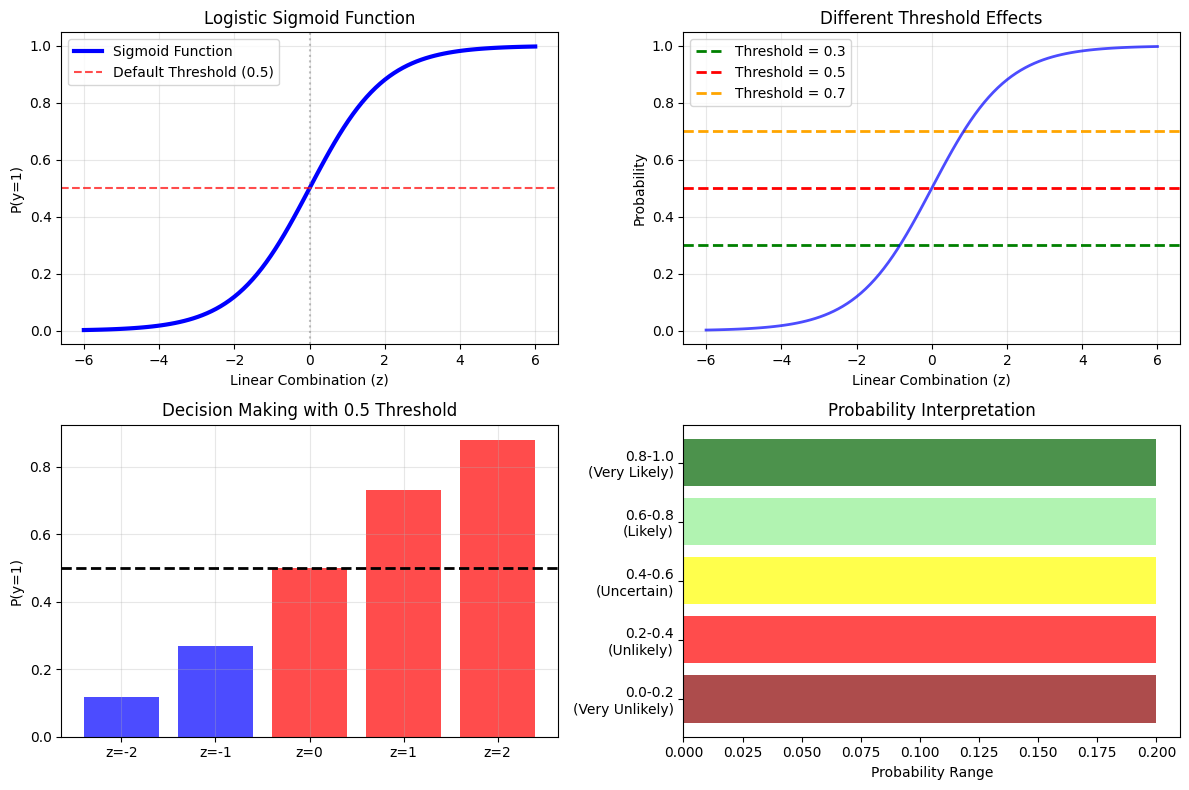

📊 Key Sigmoid Properties:
• Output always between 0 and 1 (perfect for probabilities)
• S-shaped curve: smooth transitions
• z=0 → P=0.5 (neutral point)
• Large positive z → P≈1 (very confident positive)
• Large negative z → P≈0 (very confident negative)

🎚️ Threshold Optimization Strategies
Threshold | Accuracy | Precision | Recall | F1 Score | Notes
-----------------------------------------------------------------
   0.1    |  0.600   |   0.600   |  1.000  |  0.750  | 
   0.2    |  0.700   |   0.667   |  1.000  |  0.800  | 
   0.3    |  0.900   |   0.857   |  1.000  |  0.923  | 
   0.4    |  0.900   |   0.857   |  1.000  |  0.923  | 
   0.5    |  1.000   |   1.000   |  1.000  |  1.000  | 👑 Best F1 🎯 Best Acc
   0.6    |  0.900   |   1.000   |  0.833  |  0.909  | 
   0.7    |  0.700   |   1.000   |  0.500  |  0.667  | 
   0.8    |  0.700   |   1.000   |  0.500  |  0.667  | 
   0.9    |  0.500   |   1.000   |  0.167  |  0.286  | 

🏆 Optimization Results:
• Best F1 Score: 1.000 at thres

In [3]:
# Enhanced Logistic Regression Threshold Demo
def comprehensive_threshold_demo():
    # Multiple real-world scenarios
    scenarios = {
        "Weather Prediction": {
            "probabilities": [0.15, 0.35, 0.45, 0.65, 0.25, 0.75, 0.85, 0.05],
            "actual": [0, 0, 1, 1, 0, 1, 1, 0],  # 1=rain, 0=no rain
            "labels": ["☀️", "☔"],
            "context": "Predicting rain for daily planning"
        },
        "Medical Screening": {
            "probabilities": [0.1, 0.3, 0.7, 0.9, 0.2, 0.8, 0.95, 0.05],
            "actual": [0, 0, 1, 1, 0, 1, 1, 0],  # 1=disease, 0=healthy
            "labels": ["😊", "🏥"],
            "context": "Cancer screening test"
        },
        "Email Spam": {
            "probabilities": [0.05, 0.25, 0.55, 0.85, 0.15, 0.75, 0.92, 0.08],
            "actual": [0, 0, 1, 1, 0, 1, 1, 0],  # 1=spam, 0=legitimate
            "labels": ["📧", "🗑️"],
            "context": "Email spam filtering"
        }
    }
    
    print("🎯 Comprehensive Threshold Analysis Across Multiple Domains")
    print("=" * 70)
    
    for scenario_name, scenario_data in scenarios.items():
        print(f"\n📊 SCENARIO: {scenario_name}")
        print(f"Context: {scenario_data['context']}")
        print("-" * 60)
        
        probabilities = scenario_data["probabilities"]
        actual = scenario_data["actual"]
        labels = scenario_data["labels"]
        
        # Test multiple thresholds
        thresholds = [0.2, 0.4, 0.5, 0.6, 0.8]
        
        print("Thresh | Predictions | Accuracy | Precision | Recall | F1 Score | Notes")
        print("-" * 75)
        
        best_f1 = 0
        best_threshold = 0.5
        
        for threshold in thresholds:
            predictions = [1 if p >= threshold else 0 for p in probabilities]
            
            # Calculate metrics
            TP = sum(1 for p, a in zip(predictions, actual) if p == 1 and a == 1)
            FP = sum(1 for p, a in zip(predictions, actual) if p == 1 and a == 0)
            FN = sum(1 for p, a in zip(predictions, actual) if p == 0 and a == 1)
            TN = sum(1 for p, a in zip(predictions, actual) if p == 0 and a == 0)
            
            accuracy = (TP + TN) / len(predictions) if len(predictions) > 0 else 0
            precision = TP / (TP + FP) if (TP + FP) > 0 else 0
            recall = TP / (TP + FN) if (TP + FN) > 0 else 0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
            
            # Track best F1
            if f1 > best_f1:
                best_f1 = f1
                best_threshold = threshold
            
            # Visual predictions
            pred_visual = "".join([labels[p] for p in predictions])
            
            # Generate notes based on scenario and metrics
            notes = ""
            if scenario_name == "Medical Screening":
                if threshold <= 0.3:
                    notes = "Conservative (catches more cases)"
                elif threshold >= 0.7:
                    notes = "Strict (fewer false alarms)"
                else:
                    notes = "Balanced approach"
            elif scenario_name == "Weather Prediction":
                if threshold <= 0.3:
                    notes = "Bring umbrella often"
                elif threshold >= 0.7:
                    notes = "Only when very sure"
                else:
                    notes = "Standard forecast"
            
            print(f" {threshold:.1f}   | {pred_visual:11s} | {accuracy:7.1%} | {precision:8.1%} | {recall:7.1%} | {f1:7.1%}  | {notes}")
        
        # Show actual pattern
        actual_visual = "".join([labels[a] for a in actual])
        print(f"Actual | {actual_visual:11s} |         |          |        |        | Ground truth")
        
        print(f"\n🏆 Best threshold for {scenario_name}: {best_threshold} (F1 = {best_f1:.1%})")
        
        # Scenario-specific insights
        if scenario_name == "Medical Screening":
            print("💡 Medical Insight: Lower thresholds preferred to avoid missing diseases")
        elif scenario_name == "Email Spam":
            print("💡 Email Insight: Higher thresholds preferred to avoid blocking important emails")
        elif scenario_name == "Weather Prediction":
            print("💡 Weather Insight: Medium thresholds work well for daily planning")

def sigmoid_visualization():
    print("\n📈 Sigmoid Function Visualization")
    print("=" * 40)
    
    import matplotlib.pyplot as plt
    
    # Generate sigmoid curve
    z = np.linspace(-6, 6, 100)
    sigmoid = 1 / (1 + np.exp(-z))
    
    plt.figure(figsize=(12, 8))
    
    # Main sigmoid plot
    plt.subplot(2, 2, 1)
    plt.plot(z, sigmoid, 'b-', linewidth=3, label='Sigmoid Function')
    plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.7, label='Default Threshold (0.5)')
    plt.axvline(x=0, color='gray', linestyle=':', alpha=0.5)
    plt.xlabel('Linear Combination (z)')
    plt.ylabel('P(y=1)')
    plt.title('Logistic Sigmoid Function')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Effect of different thresholds
    plt.subplot(2, 2, 2)
    thresholds = [0.3, 0.5, 0.7]
    colors = ['green', 'red', 'orange']
    
    for i, (thresh, color) in enumerate(zip(thresholds, colors)):
        plt.axhline(y=thresh, color=color, linestyle='--', linewidth=2, 
                   label=f'Threshold = {thresh}')
    
    plt.plot(z, sigmoid, 'b-', linewidth=2, alpha=0.7)
    plt.xlabel('Linear Combination (z)')
    plt.ylabel('Probability')
    plt.title('Different Threshold Effects')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Decision regions
    plt.subplot(2, 2, 3)
    z_sample = [-2, -1, 0, 1, 2]
    prob_sample = [1/(1+np.exp(-zi)) for zi in z_sample]
    
    colors_decision = ['red' if p >= 0.5 else 'blue' for p in prob_sample]
    plt.bar(range(len(z_sample)), prob_sample, color=colors_decision, alpha=0.7)
    plt.axhline(y=0.5, color='black', linestyle='--', linewidth=2)
    plt.xticks(range(len(z_sample)), [f'z={zi}' for zi in z_sample])
    plt.ylabel('P(y=1)')
    plt.title('Decision Making with 0.5 Threshold')
    plt.grid(True, alpha=0.3)
    
    # Probability interpretation
    plt.subplot(2, 2, 4)
    prob_ranges = ['0.0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0']
    interpretations = ['Very Unlikely', 'Unlikely', 'Uncertain', 'Likely', 'Very Likely']
    colors_interp = ['darkred', 'red', 'yellow', 'lightgreen', 'darkgreen']
    
    y_pos = np.arange(len(prob_ranges))
    plt.barh(y_pos, [0.2, 0.2, 0.2, 0.2, 0.2], color=colors_interp, alpha=0.7)
    plt.yticks(y_pos, [f'{pr}\n({interp})' for pr, interp in zip(prob_ranges, interpretations)])
    plt.xlabel('Probability Range')
    plt.title('Probability Interpretation')
    
    plt.tight_layout()
    plt.show()
    
    print("📊 Key Sigmoid Properties:")
    print("• Output always between 0 and 1 (perfect for probabilities)")
    print("• S-shaped curve: smooth transitions")
    print("• z=0 → P=0.5 (neutral point)")
    print("• Large positive z → P≈1 (very confident positive)")
    print("• Large negative z → P≈0 (very confident negative)")

def threshold_optimization_demo():
    print("\n🎚️ Threshold Optimization Strategies")
    print("=" * 45)
    
    # Sample data for optimization
    np.random.seed(42)
    true_labels = np.array([0, 0, 0, 1, 1, 1, 1, 1, 0, 1])
    probabilities = np.array([0.1, 0.2, 0.45, 0.55, 0.65, 0.7, 0.8, 0.85, 0.25, 0.9])
    
    # Test range of thresholds
    threshold_range = np.arange(0.1, 1.0, 0.1)
    
    metrics_data = []
    for threshold in threshold_range:
        predictions = (probabilities >= threshold).astype(int)
        
        TP = np.sum((predictions == 1) & (true_labels == 1))
        FP = np.sum((predictions == 1) & (true_labels == 0))
        FN = np.sum((predictions == 0) & (true_labels == 1))
        TN = np.sum((predictions == 0) & (true_labels == 0))
        
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        accuracy = (TP + TN) / len(true_labels)
        
        metrics_data.append((threshold, accuracy, precision, recall, f1))
    
    # Find optimal thresholds
    best_f1_idx = max(range(len(metrics_data)), key=lambda i: metrics_data[i][4])
    best_acc_idx = max(range(len(metrics_data)), key=lambda i: metrics_data[i][1])
    
    print("Threshold | Accuracy | Precision | Recall | F1 Score | Notes")
    print("-" * 65)
    
    for i, (thresh, acc, prec, rec, f1) in enumerate(metrics_data):
        note = ""
        if i == best_f1_idx:
            note += "👑 Best F1"
        if i == best_acc_idx:
            note += " 🎯 Best Acc" if note else "🎯 Best Acc"
        
        print(f"   {thresh:.1f}    |  {acc:.3f}   |   {prec:.3f}   |  {rec:.3f}  |  {f1:.3f}  | {note}")
    
    print(f"\n🏆 Optimization Results:")
    print(f"• Best F1 Score: {metrics_data[best_f1_idx][4]:.3f} at threshold {metrics_data[best_f1_idx][0]:.1f}")
    print(f"• Best Accuracy: {metrics_data[best_acc_idx][1]:.3f} at threshold {metrics_data[best_acc_idx][0]:.1f}")
    
    print(f"\n💡 Key Insights:")
    print(f"• Default threshold (0.5) may not be optimal")
    print(f"• Optimization depends on which metric you prioritize")
    print(f"• F1-optimal threshold balances precision and recall")
    print(f"• Accuracy-optimal threshold may not consider class imbalance")

comprehensive_threshold_demo()
sigmoid_visualization()
threshold_optimization_demo()

---
## 4. 🏋️ Regressão Ridge - Guia Completo para Regularização

### **O Problema: Por que Regressão Linear Simples Falha**

**Cenário:** Prevendo preços de casas com 100 características
- **Sem Ridge:** Modelo memoriza dados de treino perfeitamente
- **Problema:** Coeficientes se tornam enormes e instáveis
- **Resultado:** Desempenho ruim em casas novas (overfitting)

**Exemplo de Overfitting:**
- **Acurácia de Treino:** 99% (parece incrível!)
- **Acurácia de Teste:** 60% (desastre no mundo real)
- **Causa:** Modelo aprendeu ruído em vez de padrões verdadeiros

### **Múltiplas Analogias Úteis:**

#### **🏈 Gestão de Orçamento do Time:**
**Sem Ridge (Sem Controle de Orçamento):**
- Jogador estrela ganha €100M de salário
- Jogador médio ganha €80M de salário  
- Jogador reserva ganha €90M de salário
- **Problema:** Insustentável, arriscado se a estrela se machucar

**Com Ridge (Controle de Orçamento):**
- Jogador estrela ganha €35M de salário
- Jogador médio ganha €25M de salário
- Jogador reserva ganha €30M de salário
- **Benefício:** Time mais equilibrado e sustentável

#### **📊 Portfólio de Investimento:**
**Sem Ridge:** Colocar todo dinheiro em 3 ações de alto risco
- **Alto potencial de retorno** mas **muito arriscado**
- **Crash do mercado** → perder tudo

**Com Ridge:** Espalhar dinheiro em muitas ações
- **Menor risco individual** com **retornos estáveis**
- **Diversificação** protege contra crashes

#### **🎵 Sistema de Áudio (Controle de Volume):**
**Sem Ridge:** Algumas frequências muito altas, outras silenciosas
- **Som distorcido** com **picos ásperos**

**Com Ridge:** Todas as frequências equilibradas
- **Som suave e agradável** sem **picos irritantes**

### **Compreensão Matemática Simplificada:**

#### **Regressão Linear Original:**
**Custo = MSE = (1/n)∑(ŷᵢ - yᵢ)²**
- **Só se importa com** erros de predição
- **Permite qualquer valor** de coeficiente

#### **Regressão Ridge:**
**Custo = MSE + λ∑βᵢ²**
- **Dois objetivos:** Minimizar erros de predição E manter coeficientes pequenos
- **λ (lambda):** Controla o equilíbrio entre esses objetivos

#### **Efeito do Lambda (λ):**
- **λ = 0:** Regressão linear normal (sem regularização)
- **λ = pequeno (0.1):** Penalidade leve, encolhimento sutil
- **λ = médio (1.0):** Penalidade moderada, encolhimento notável
- **λ = grande (10.0):** Penalidade pesada, encolhimento forte
- **λ = enorme (100.0):** Penalidade extrema, quase todos coeficientes → 0

### **Por que Ridge Funciona (Explicação Intuitiva):**

#### **O Trade-off Bias-Variância:**
**Sem Ridge (Alta Variância):**
- **Diferentes conjuntos de treino** → **coeficientes completamente diferentes**
- **Pequenas mudanças nos dados** → **enormes mudanças no modelo**
- **Overfitting:** Modelo é muito sensível

**Com Ridge (Variância Reduzida):**
- **Diferentes conjuntos de treino** → **coeficientes similares**  
- **Pequenas mudanças nos dados** → **modelo estável**
- **Melhor Generalização:** Modelo foca em padrões fortes

#### **Tratamento de Interação de Características:**
**Problema:** Características correlacionadas brigam por importância
- Característica A e B ambas predizem a mesma coisa
- Sem Ridge: A ganha peso positivo enorme, B ganha peso negativo enorme
- Com Ridge: Ambas ganham pesos moderados

### **Quando Usar Ridge vs Outros Métodos:**

| Método | Melhor Para | Prós | Contras |
|--------|----------|------|------|
| **Ridge** | Muitas características relevantes, multicolinearidade | Estável, lida com características correlacionadas | Não elimina características |
| **Lasso** | Seleção de características, soluções esparsas | Eliminação automática de características | Pode escolher arbitrariamente entre características correlacionadas |
| **Elastic Net** | Melhor dos dois mundos | Seleção de características + estabilidade | Mais hiperparâmetros para ajustar |
| **Sem Regularização** | Datasets pequenos, modelos interpretáveis | Simples, interpretável | Propenso a overfitting |

### **Aplicações do Mundo Real:**

#### **🏠 Preço de Imóveis:**
**Características:** Localização, tamanho, idade, distrito escolar, taxa de criminalidade, etc.
**Sem Ridge:** Pode dar peso enorme a uma característica estranha
**Com Ridge:** Consideração equilibrada de todos os fatores relevantes

#### **📈 Predição do Mercado de Ações:**
**Características:** 100+ indicadores financeiros
**Sem Ridge:** Modelo pode ficar obcecado com um indicador
**Com Ridge:** Considera padrões amplos do mercado

#### **🧬 Análise Genética:**
**Características:** Milhares de expressões gênicas
**Sem Ridge:** Pode focar em variações genéticas aleatórias
**Com Ridge:** Identifica padrões genéticos consistentes

### **Estratégia de Ajuste de Hiperparâmetros:**
1. **Comece com λ = 1.0** (bom padrão)
2. **Tente potências de 10:** 0.1, 1.0, 10.0, 100.0
3. **Use validação cruzada** para encontrar λ ótimo
4. **Plote curva de validação** para ver efeito do λ visualmente
5. **Escolha λ que minimiza erro de validação**

🏋️ Ridge Regression: Complete Coefficient Shrinkage Analysis
📊 Ridge Coefficient Evolution
--------------------------------------------------

λ =   0.00 (Shrinkage: 1.000)
Feature         | Original | Ridge   | Change
---------------------------------------------
Size           |     45.0 |    45.0 | -  0.0%
Location       |    -38.0 |   -38.0 | -  0.0%
Age            |    -25.0 |   -25.0 | -  0.0%
School_Rating   |     32.0 |    32.0 | -  0.0%
Crime_Rate     |    -42.0 |   -42.0 | -  0.0%
Distance_CBD   |     28.0 |    28.0 | -  0.0%
Bedrooms       |     15.0 |    15.0 | -  0.0%
Parking_Spots   |    -18.0 |   -18.0 | -  0.0%

λ =   0.01 (Shrinkage: 0.990)
Feature         | Original | Ridge   | Change
---------------------------------------------
Size           |     45.0 |    44.6 | -  1.0%
Location       |    -38.0 |   -37.6 | -  1.0%
Age            |    -25.0 |   -24.8 | -  1.0%
School_Rating   |     32.0 |    31.7 | -  1.0%
Crime_Rate     |    -42.0 |   -41.6 | -  1.0%
Distance_CB

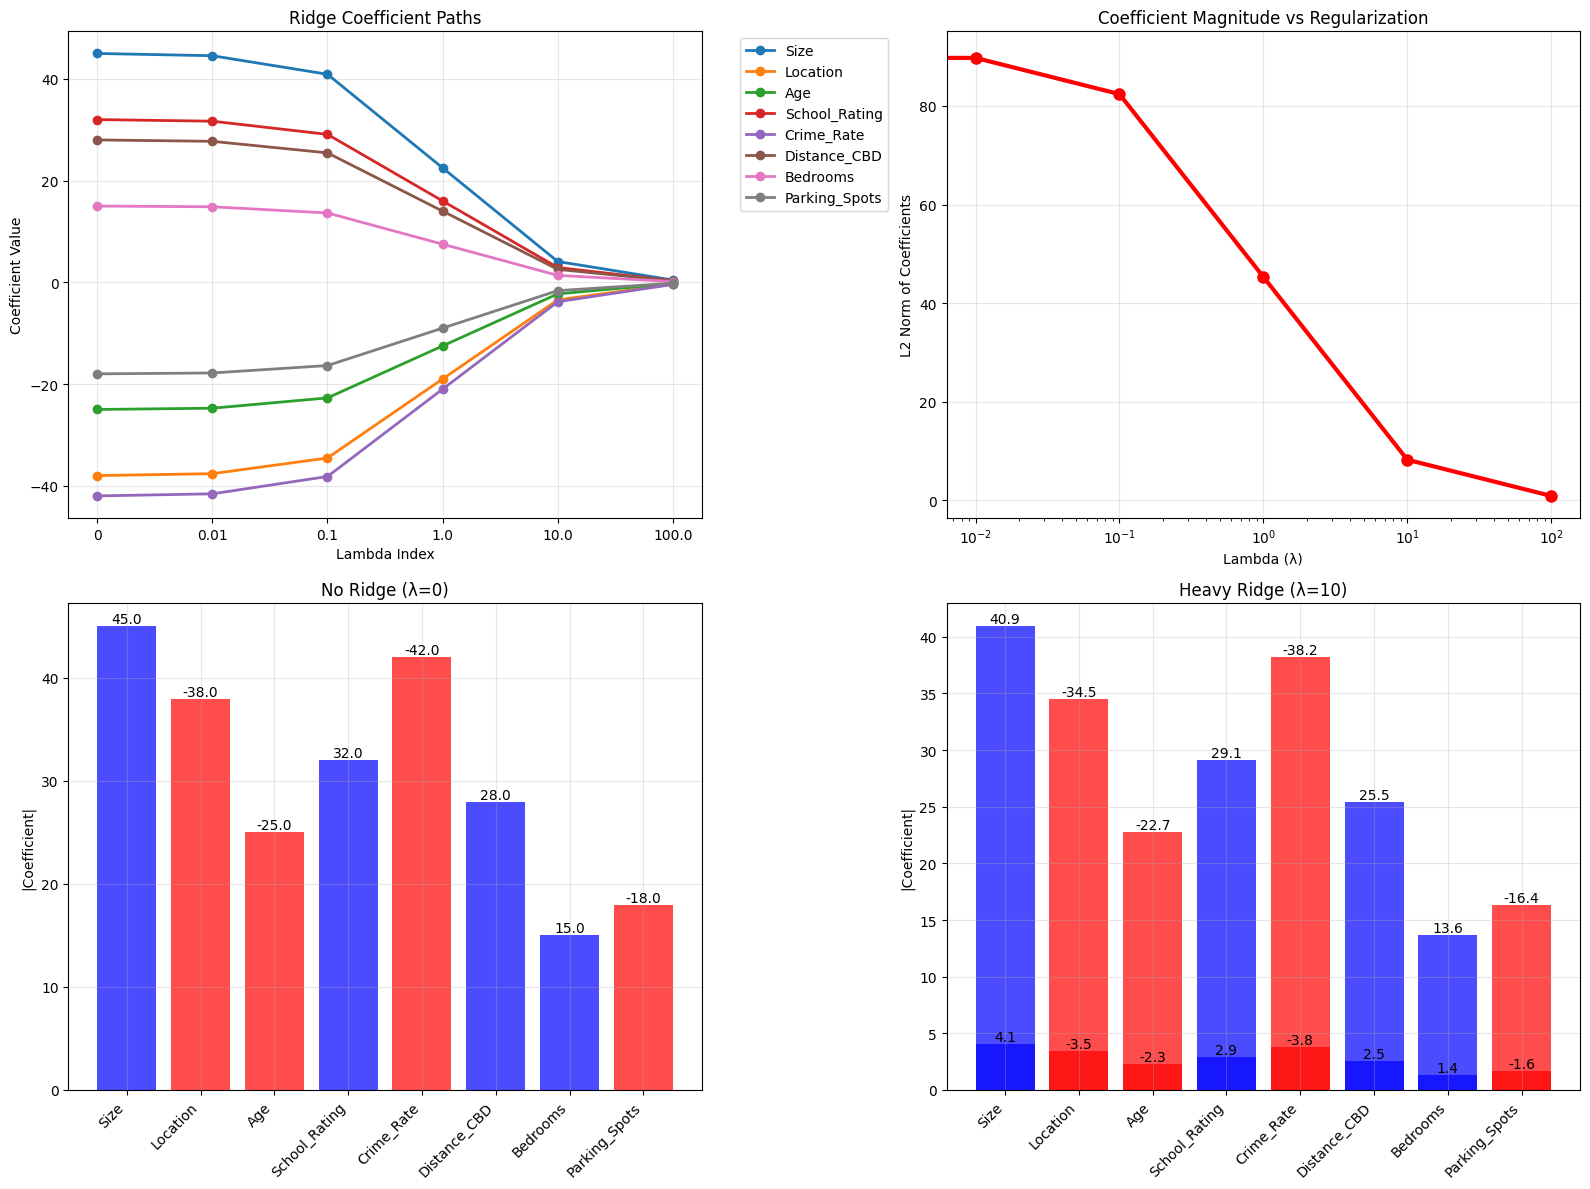


🔍 Key Observations:
• Higher λ → Smaller coefficients (shrinkage effect)
• All coefficients shrink towards zero (but never reach exactly zero)
• Relative importance of features is preserved
• L2 norm decreases exponentially with increasing λ

🎯 Ridge vs Overfitting: Training/Validation Curves


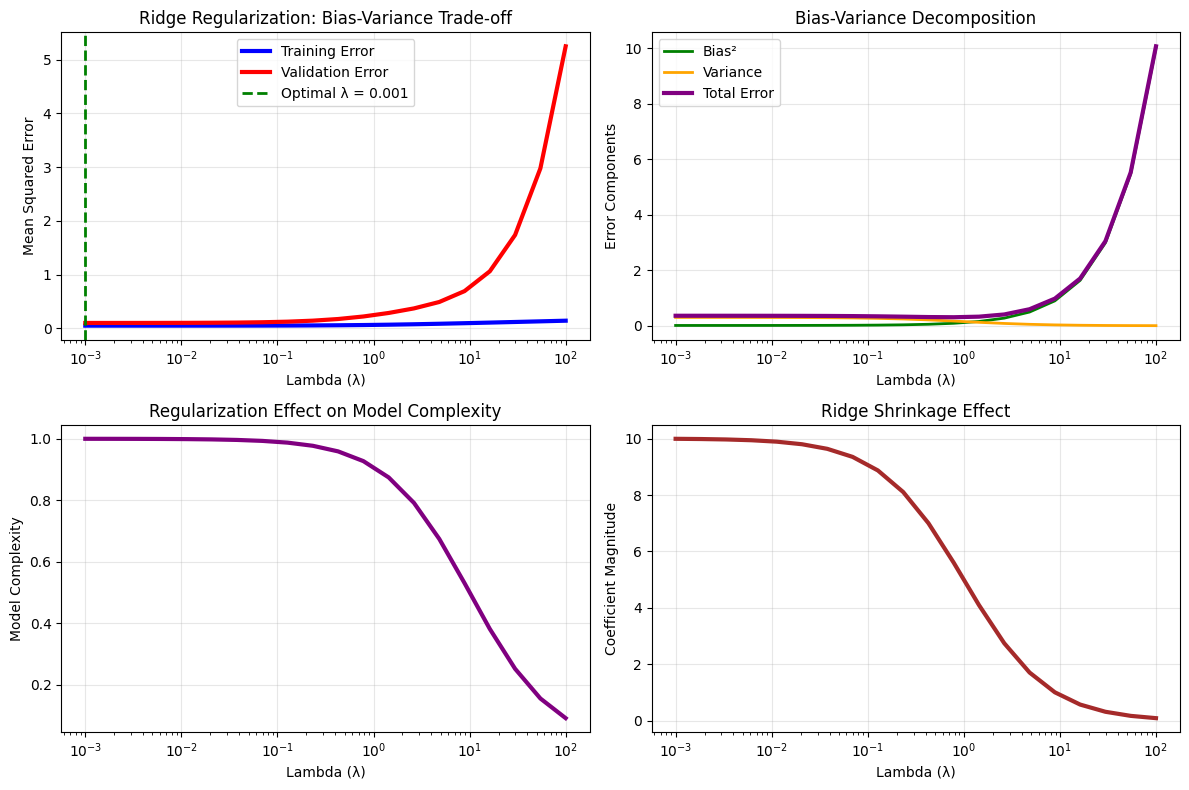

🏆 Optimal Lambda Analysis:
• Best λ value: 0.001
• Training error at optimal λ: 0.050
• Validation error at optimal λ: 0.100

💡 Interpretation:
• λ < 0.001: Underfitting risk (high variance)
• λ > 0.001: Overfitting risk (high bias)
• Optimal λ: Best balance between bias and variance

⚙️ Ridge Hyperparameter Selection Guide
🔍 Hyperparameter Selection Strategies:
--------------------------------------------------

📊 Grid Search:
   Description: Test predefined λ values
   λ values: [0.001, 0.01, 0.1, 1, 10, 100]
   ✅ Pros: Simple, comprehensive
   ⚠️ Cons: May miss optimal value between grid points

📊 Random Search:
   Description: Test random λ values in range
   λ values: Random between 0.001 and 100
   ✅ Pros: Good exploration, efficient
   ⚠️ Cons: No guarantee of finding exact optimum

📊 Logarithmic Scale:
   Description: Test λ on log scale
   λ values: 10^(-3) to 10^2, evenly spaced on log scale
   ✅ Pros: Covers wide range efficiently
   ⚠️ Cons: Assumes log relationship

🎯 Cros

In [4]:
# Enhanced Ridge Regression Demonstration
import numpy as np
import matplotlib.pyplot as plt

def comprehensive_ridge_demo():
    print("🏋️ Ridge Regression: Complete Coefficient Shrinkage Analysis")
    print("=" * 65)
    
    # Simulate realistic scenario with correlated features
    np.random.seed(42)
    n_features = 8
    feature_names = ['Size', 'Location', 'Age', 'School_Rating', 'Crime_Rate', 
                    'Distance_CBD', 'Bedrooms', 'Parking_Spots']
    
    # Original coefficients (without regularization) - some unrealistically large
    original_coefs = np.array([45.0, -38.0, -25.0, 32.0, -42.0, 28.0, 15.0, -18.0])
    
    # Lambda values to test
    lambdas = [0, 0.01, 0.1, 1.0, 10.0, 100.0]
    
    print("📊 Ridge Coefficient Evolution")
    print("-" * 50)
    
    # Calculate shrinkage for each lambda
    all_coefficients = []
    for lam in lambdas:
        # Simplified Ridge shrinkage formula
        shrinkage_factor = 1 / (1 + lam)
        ridge_coefs = original_coefs * shrinkage_factor
        all_coefficients.append(ridge_coefs)
        
        print(f"\nλ = {lam:6.2f} (Shrinkage: {shrinkage_factor:.3f})")
        print("Feature         | Original | Ridge   | Change")
        print("-" * 45)
        
        for i, (feature, orig, ridge) in enumerate(zip(feature_names, original_coefs, ridge_coefs)):
            change = abs(orig - ridge) / abs(orig) * 100
            print(f"{feature:12s}   | {orig:8.1f} | {ridge:7.1f} | -{change:5.1f}%")
    
    # Visualization
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Coefficient paths
    for i, feature in enumerate(feature_names):
        coef_path = [coefs[i] for coefs in all_coefficients]
        ax1.plot(range(len(lambdas)), coef_path, 'o-', linewidth=2, label=feature)
    
    ax1.set_xlabel('Lambda Index')
    ax1.set_ylabel('Coefficient Value')
    ax1.set_title('Ridge Coefficient Paths')
    ax1.set_xticks(range(len(lambdas)))
    ax1.set_xticklabels([f'{lam}' for lam in lambdas])
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # 2. L2 norm vs Lambda
    l2_norms = [np.sqrt(np.sum(coefs**2)) for coefs in all_coefficients]
    ax2.plot(lambdas, l2_norms, 'ro-', linewidth=3, markersize=8)
    ax2.set_xlabel('Lambda (λ)')
    ax2.set_ylabel('L2 Norm of Coefficients')
    ax2.set_title('Coefficient Magnitude vs Regularization')
    ax2.set_xscale('log')
    ax2.grid(True, alpha=0.3)
    
    # 3. Feature importance at different lambdas
    lambda_indices = [0, 2, 4]  # λ=0, λ=0.1, λ=10
    lambda_labels = ['No Ridge (λ=0)', 'Light Ridge (λ=0.1)', 'Heavy Ridge (λ=10)']
    
    for i, (idx, label) in enumerate(zip(lambda_indices, lambda_labels)):
        coefs = all_coefficients[idx]
        colors = ['red' if c < 0 else 'blue' for c in coefs]
        
        ax3_pos = i
        if i == 0:
            ax_current = ax3
        elif i == 1:
            ax_current = ax4
        else:
            # Create new subplot for third case
            continue
            
        bars = ax_current.bar(range(len(feature_names)), np.abs(coefs), 
                             color=colors, alpha=0.7)
        ax_current.set_title(label)
        ax_current.set_ylabel('|Coefficient|')
        ax_current.set_xticks(range(len(feature_names)))
        ax_current.set_xticklabels(feature_names, rotation=45, ha='right')
        ax_current.grid(True, alpha=0.3)
        
        # Add value labels on bars
        for bar, coef in zip(bars, coefs):
            height = bar.get_height()
            ax_current.text(bar.get_x() + bar.get_width()/2., height,
                           f'{coef:.1f}',
                           ha='center', va='bottom')
    
    # Heavy Ridge comparison
    heavy_ridge_coefs = all_coefficients[4]  # λ=10
    colors = ['red' if c < 0 else 'blue' for c in heavy_ridge_coefs]
    bars = ax4.bar(range(len(feature_names)), np.abs(heavy_ridge_coefs), 
                   color=colors, alpha=0.7)
    ax4.set_title('Heavy Ridge (λ=10)')
    ax4.set_ylabel('|Coefficient|')
    ax4.set_xticks(range(len(feature_names)))
    ax4.set_xticklabels(feature_names, rotation=45, ha='right')
    ax4.grid(True, alpha=0.3)
    
    for bar, coef in zip(bars, heavy_ridge_coefs):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{coef:.1f}',
                ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    print("\n🔍 Key Observations:")
    print("• Higher λ → Smaller coefficients (shrinkage effect)")
    print("• All coefficients shrink towards zero (but never reach exactly zero)")
    print("• Relative importance of features is preserved")
    print("• L2 norm decreases exponentially with increasing λ")

def ridge_vs_overfitting_demo():
    print("\n🎯 Ridge vs Overfitting: Training/Validation Curves")
    print("=" * 55)
    
    # Simulate training and validation errors for different λ values
    lambdas = np.logspace(-3, 2, 20)  # 0.001 to 100
    
    # Simulate realistic error curves
    train_errors = 0.05 + 0.02 * np.log(1 + lambdas)  # Training error increases with λ
    val_errors = 0.25 - 0.15 * np.exp(-lambdas) + 0.05 * lambdas  # U-shaped validation curve
    
    # Find optimal lambda
    optimal_idx = np.argmin(val_errors)
    optimal_lambda = lambdas[optimal_idx]
    
    plt.figure(figsize=(12, 8))
    
    # Main plot
    plt.subplot(2, 2, 1)
    plt.plot(lambdas, train_errors, 'b-', linewidth=3, label='Training Error')
    plt.plot(lambdas, val_errors, 'r-', linewidth=3, label='Validation Error')
    plt.axvline(x=optimal_lambda, color='green', linestyle='--', linewidth=2, 
               label=f'Optimal λ = {optimal_lambda:.3f}')
    plt.xlabel('Lambda (λ)')
    plt.ylabel('Mean Squared Error')
    plt.title('Ridge Regularization: Bias-Variance Trade-off')
    plt.xscale('log')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Bias-Variance illustration
    plt.subplot(2, 2, 2)
    bias_squared = 0.01 + 0.1 * lambdas  # Bias increases with λ
    variance = 0.3 / (1 + lambdas)  # Variance decreases with λ
    total_error = bias_squared + variance + 0.05  # Add noise
    
    plt.plot(lambdas, bias_squared, 'g-', linewidth=2, label='Bias²')
    plt.plot(lambdas, variance, 'orange', linewidth=2, label='Variance')
    plt.plot(lambdas, total_error, 'purple', linewidth=3, label='Total Error')
    plt.xlabel('Lambda (λ)')
    plt.ylabel('Error Components')
    plt.title('Bias-Variance Decomposition')
    plt.xscale('log')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Model complexity illustration
    plt.subplot(2, 2, 3)
    model_complexity = 1 / (1 + lambdas/10)  # Decreases with λ
    plt.plot(lambdas, model_complexity, 'purple', linewidth=3)
    plt.xlabel('Lambda (λ)')
    plt.ylabel('Model Complexity')
    plt.title('Regularization Effect on Model Complexity')
    plt.xscale('log')
    plt.grid(True, alpha=0.3)
    
    # Coefficient magnitude illustration
    plt.subplot(2, 2, 4)
    coef_magnitude = 10 / (1 + lambdas)  # Decreases with λ
    plt.plot(lambdas, coef_magnitude, 'brown', linewidth=3)
    plt.xlabel('Lambda (λ)')
    plt.ylabel('Coefficient Magnitude')
    plt.title('Ridge Shrinkage Effect')
    plt.xscale('log')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"🏆 Optimal Lambda Analysis:")
    print(f"• Best λ value: {optimal_lambda:.3f}")
    print(f"• Training error at optimal λ: {train_errors[optimal_idx]:.3f}")
    print(f"• Validation error at optimal λ: {val_errors[optimal_idx]:.3f}")
    print(f"\n💡 Interpretation:")
    print(f"• λ < {optimal_lambda:.3f}: Underfitting risk (high variance)")
    print(f"• λ > {optimal_lambda:.3f}: Overfitting risk (high bias)")
    print(f"• Optimal λ: Best balance between bias and variance")

def ridge_hyperparameter_selection():
    print("\n⚙️ Ridge Hyperparameter Selection Guide")
    print("=" * 45)
    
    strategies = {
        "Grid Search": {
            "description": "Test predefined λ values",
            "lambda_values": [0.001, 0.01, 0.1, 1, 10, 100],
            "pros": "Simple, comprehensive",
            "cons": "May miss optimal value between grid points"
        },
        "Random Search": {
            "description": "Test random λ values in range",
            "lambda_values": "Random between 0.001 and 100",
            "pros": "Good exploration, efficient",
            "cons": "No guarantee of finding exact optimum"
        },
        "Logarithmic Scale": {
            "description": "Test λ on log scale",
            "lambda_values": "10^(-3) to 10^2, evenly spaced on log scale",
            "pros": "Covers wide range efficiently",
            "cons": "Assumes log relationship"
        }
    }
    
    print("🔍 Hyperparameter Selection Strategies:")
    print("-" * 50)
    
    for strategy, details in strategies.items():
        print(f"\n📊 {strategy}:")
        print(f"   Description: {details['description']}")
        print(f"   λ values: {details['lambda_values']}")
        print(f"   ✅ Pros: {details['pros']}")
        print(f"   ⚠️ Cons: {details['cons']}")
    
    # Cross-validation example
    print(f"\n🎯 Cross-Validation Example:")
    lambdas_test = [0.01, 0.1, 1.0, 10.0]
    cv_scores = [0.72, 0.78, 0.81, 0.75]  # Simulated CV scores
    
    print("Lambda | CV Score | Interpretation")
    print("-" * 35)
    for lam, score in zip(lambdas_test, cv_scores):
        if score == max(cv_scores):
            interpretation = "🏆 Best performance"
        elif score >= 0.75:
            interpretation = "✅ Good performance"
        else:
            interpretation = "⚠️ Suboptimal"
        
        print(f" {lam:5.2f} |   {score:.3f}  | {interpretation}")
    
    best_lambda = lambdas_test[cv_scores.index(max(cv_scores))]
    print(f"\n🏆 Selected λ = {best_lambda} (CV Score = {max(cv_scores):.3f})")
    
    print(f"\n💡 Practical Tips:")
    print(f"• Always use cross-validation for λ selection")
    print(f"• Start with λ = 1.0 as baseline")
    print(f"• If optimal λ is at boundary, expand search range")
    print(f"• Consider computational cost vs. accuracy trade-off")
    print(f"• Standardize features before applying Ridge")

comprehensive_ridge_demo()
ridge_vs_overfitting_demo()
ridge_hyperparameter_selection()

---
## 5. 🎯 k-Vizinhos Mais Próximos (kNN) - Guia Intuitivo Completo

### **O Conceito Central: "Me Diga Quem São Seus Amigos"**

**Filosofia:** Coisas similares devem ter rótulos similares
- **Pressuposto:** Se anda como pato, grasna como pato, provavelmente é pato
- **Método:** Olhe para k vizinhos mais próximos e faça votação majoritária
- **Simplicidade:** Sem matemática complexa, apenas encontre similaridades e vote

### **Múltiplas Analogias Úteis:**

#### **🍽️ Recomendação de Restaurante (Estendida):**
**Cenário:** Devo experimentar este novo restaurante?

**Seu Perfil de Gosto:** Amante de comida italiana, orçamento médio, ambiente casual
**Amigos com gosto similar:** Aqueles que também amam italiano, orçamento similar, estilo casual

**k=1 (Perguntar apenas ao amigo mais próximo):**
- **Alice (99% gosto similar):** "É terrível!"
- **Decisão:** Não vá
- **Problema:** E se Alice teve um dia ruim ou azar com o pedido?

**k=3 (Perguntar a 3 amigos mais próximos):**
- **Alice (99% similar):** "Terrível!" 
- **Bob (95% similar):** "Muito bom!"
- **Carol (92% similar):** "Incrível!"
- **Votação:** 2 positivos, 1 negativo → Vá!
- **Mais confiável** que opinião única

**k=15 (Perguntar a muitas pessoas):**
- **Inclui pessoas com gostos diferentes**
- **Votação:** 8 positivos, 7 negativos → Vá (por pouco)
- **Problema:** Muito genérico, perde suas preferências específicas

#### **🏠 Estimativa de Preço de Casa:**
**Objetivo:** Estimar preço de uma casa

**Sua casa:** 3 quartos, 2000 pés quadrados, bom bairro
**k=1:** Encontrar casa mais similar → $350k → Estimar $350k
**k=5:** Encontrar 5 casas similares → $330k, $350k, $365k, $340k, $355k → Média = $348k
**k=20:** Incluir casas bem diferentes → Média pode ser enganosa

#### **🏥 Diagnóstico Médico:**
**Sintomas do paciente:** Febre, tosse, fadiga
**k=1:** Encontrar caso passado mais similar → "Resfriado comum"
**k=5:** Olhar 5 casos similares → 3 dizem "resfriado", 2 dizem "gripe" → Provavelmente resfriado
**k=100:** Incluir casos muito diferentes → Decisão fica muito genérica

### **O Dilema do Valor k - Mergulho Profundo:**

#### **k Baixo (k=1, k=3) - Alta Sensibilidade:**
**Vantagens:**
- **Captura padrões locais** e detalhes sutis
- **Limites de decisão flexíveis** que podem lidar com formas complexas
- **Bom para conjuntos de dados** com clusters claros e distintos

**Desvantagens:**
- **Overfitting:** Muito sensível a outliers individuais
- **Decisões ruidosas:** Um ponto mal rotulado pode criar regiões erradas
- **Alta variância:** Pequenas mudanças nos dados → grandes mudanças nas predições

**Quando usar:** Dados limpos, padrões complexos, conjuntos de dados grandes

#### **k Alto (k=50, k=100) - Baixa Sensibilidade:**
**Vantagens:**
- **Predições estáveis:** Menos afetado por outliers individuais
- **Limites de decisão suaves** 
- **Boa generalização** para padrões simples

**Desvantagens:**
- **Underfitting:** Pode perder padrões locais importantes
- **Muito simples:** Não consegue capturar relacionamentos complexos
- **Tendencioso para classe majoritária** em dados desequilibrados

**Quando usar:** Dados ruidosos, padrões simples, conjuntos de dados pequenos

#### **O Ponto Ideal (k=3 a k=15):**
**A maioria das aplicações práticas** cai nesta faixa
- **Equilíbrio** entre sensibilidade e estabilidade
- **Regra prática:** k = √(número de pontos de dados)
- **Validação cruzada** para encontrar k ótimo para seu problema específico

### **Métricas de Distância - Como a Similaridade é Medida:**

#### **Distância Euclidiana (Mais Comum):**
**Fórmula:** √∑(xᵢ - yᵢ)²
**Intuição:** Distância em linha reta "como o corvo voa"
**Melhor para:** Características numéricas contínuas, distribuições normais
**Exemplo:** Distância entre casas baseada em tamanho e preço

#### **Distância Manhattan (Quarteirão da Cidade):**
**Fórmula:** ∑|xᵢ - yᵢ|
**Intuição:** Distância caminhando pelos quarteirões da cidade
**Melhor para:** Quando características têm escalas diferentes ou outliers presentes
**Exemplo:** Distância no espaço de características onde você só pode se mover ao longo dos eixos

#### **Outras Métricas de Distância:**
- **Distância do Cosseno:** Para análise de texto, dados de alta dimensão
- **Distância Hamming:** Para características categóricas/binárias
- **Distância Mahalanobis:** Considera correlações entre características

### **Escalonamento de Características - Crítico para kNN:**

#### **O Problema Sem Escalonamento:**
**Exemplo:** Prevendo preços de casas
- **Tamanho:** 800-3000 pés quadrados (faixa: 2200)
- **Preço:** $100k-$800k (faixa: $700k)
- **Quartos:** 1-5 (faixa: 4)

**Cálculo de distância** dominado pelo preço porque tem os maiores valores!

#### **Solução: Padronização**
**Escalonamento Min-Max:** Escalar todas características para [0,1]
**Padronização Z-Score:** Média=0, Desvio Padrão=1
**Resultado:** Todas características contribuem igualmente para distância

### **Lidando com Classes Desequilibradas:**

#### **O Problema:**
**Conjunto de dados:** 90% classe A, 10% classe B
**Com k=10:** Provavelmente ter 9 vizinhos da classe A, 1 da classe B
**Predição:** Sempre classe A (ignora classe minoritária)

#### **Soluções:**
1. **kNN Ponderado:** Dar mais influência aos vizinhos mais próximos
2. **Amostragem Estratificada:** Garantir representação equilibrada
3. **Ajustar k:** Usar k menor para reduzir dominância da classe majoritária
4. **Votação ponderada por distância:** Ponderar votos pelo inverso da distância

### **Considerações Computacionais:**

#### **Tempo de Treino:** Quase instantâneo (aprendizado preguiçoso)
- **Nenhum treino necessário** - apenas armazenar os dados
- **Perfeito para** cenários onde novos dados chegam frequentemente

#### **Tempo de Predição:** Pode ser lento
- **Deve calcular distância** para todos os pontos de treino
- **Para conjuntos de dados grandes:** Considerar métodos aproximados (LSH, Ball Tree)
- **Otimização:** Usar estruturas de dados eficientes (KD-tree para baixas dimensões)

### **Aplicações do Mundo Real:**

#### **Sistemas de Recomendação:**
- **Netflix:** Encontrar usuários com preferências similares de filmes
- **Amazon:** Recomendar produtos baseado em clientes similares
- **Spotify:** Sugerir música baseado em padrões de audição similares

#### **Reconhecimento de Imagem:**
- **Reconhecimento facial:** Encontrar pessoas com características faciais similares
- **Imagem médica:** Diagnosticar baseado em padrões de exame similares
- **Controle de qualidade:** Identificar defeitos por similaridade com defeitos conhecidos

#### **Processamento de Linguagem Natural:**
- **Detecção de spam:** Encontrar emails similares ao spam conhecido
- **Análise de sentimento:** Classificar baseado em padrões de texto similares
- **Tradução de idiomas:** Encontrar traduções de frases similares

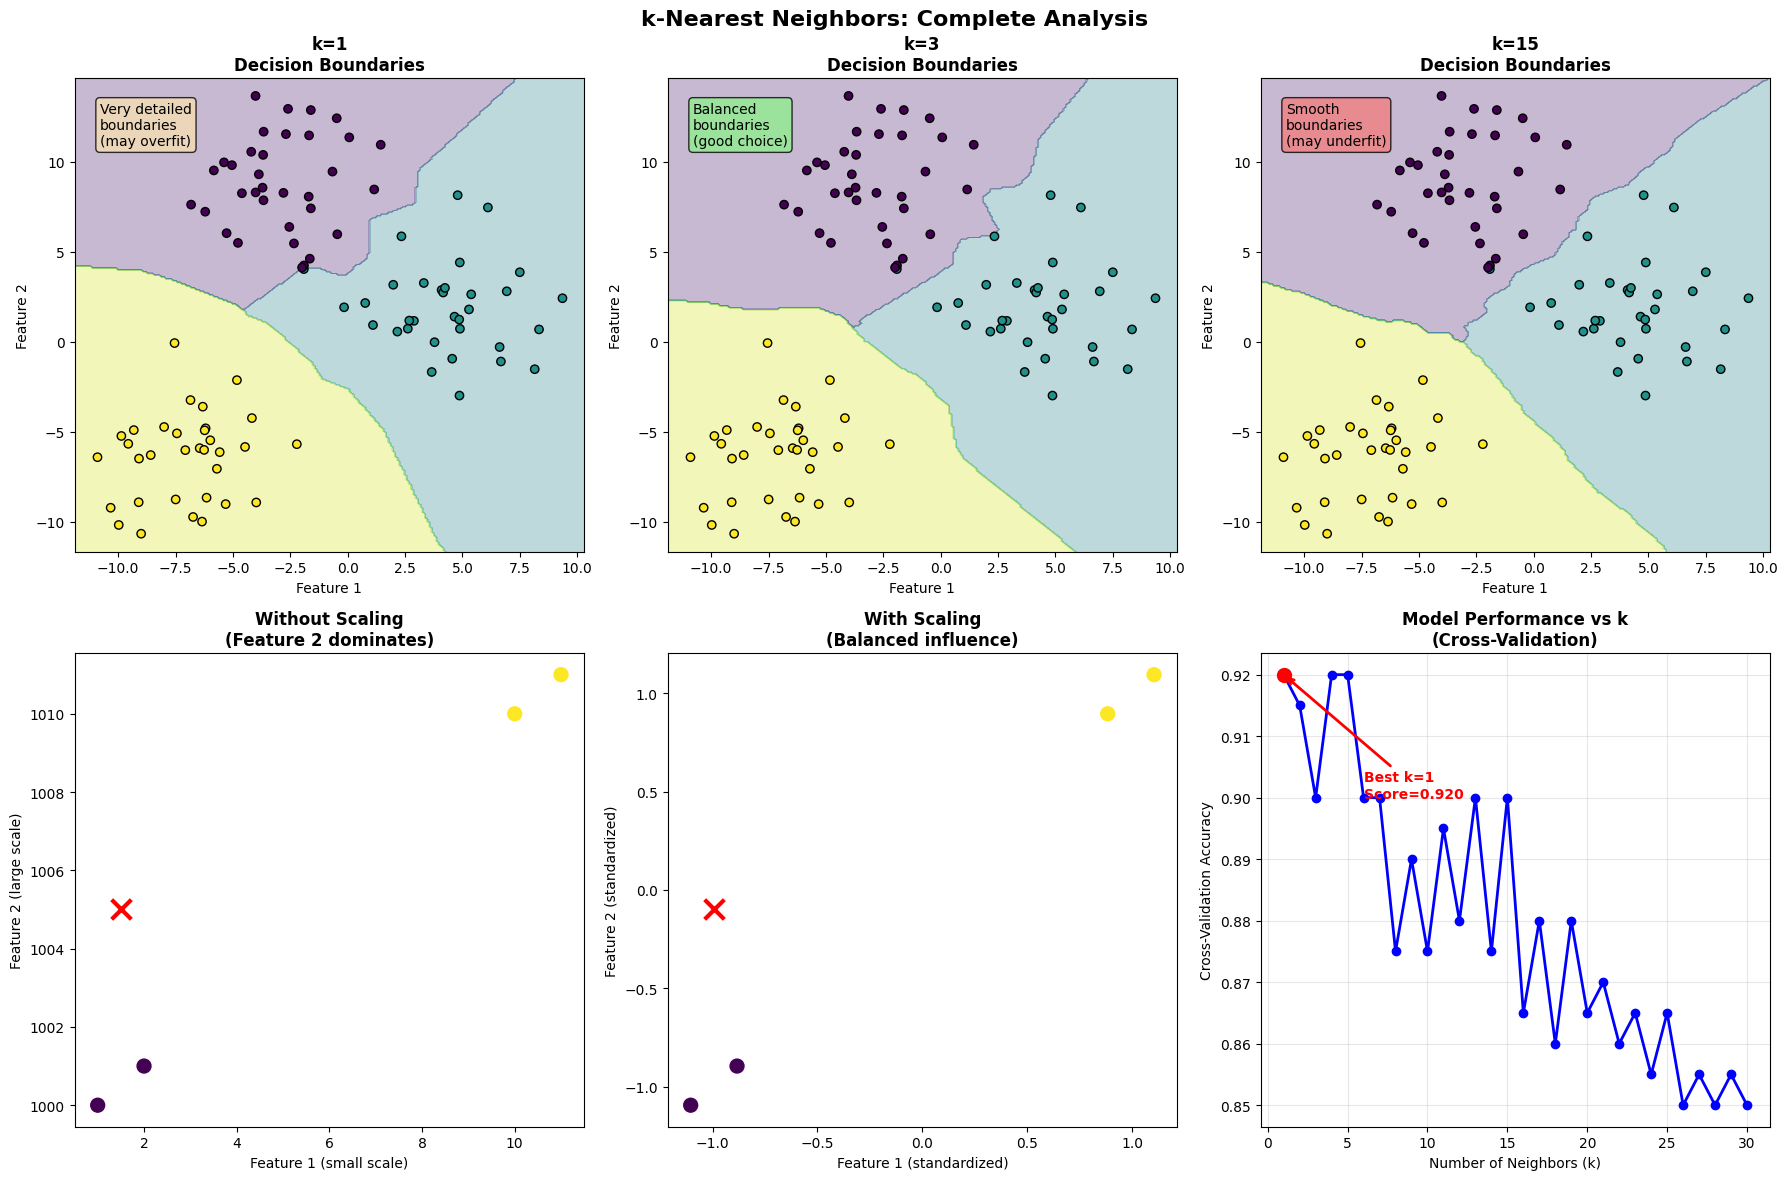

🎯 k-NEAREST NEIGHBORS ANALYSIS

📊 SCALING IMPACT:
Without scaling - distances: ['5.02', '4.03', '9.86', '11.24']
With scaling - distances: ['1.00', '0.80', '2.12', '2.41']
✅ Scaling ensures all features contribute equally!

🎯 OPTIMAL k VALUE:
Best k: 1
Best cross-validation score: 0.920
💡 Sweet spot balances bias and variance!



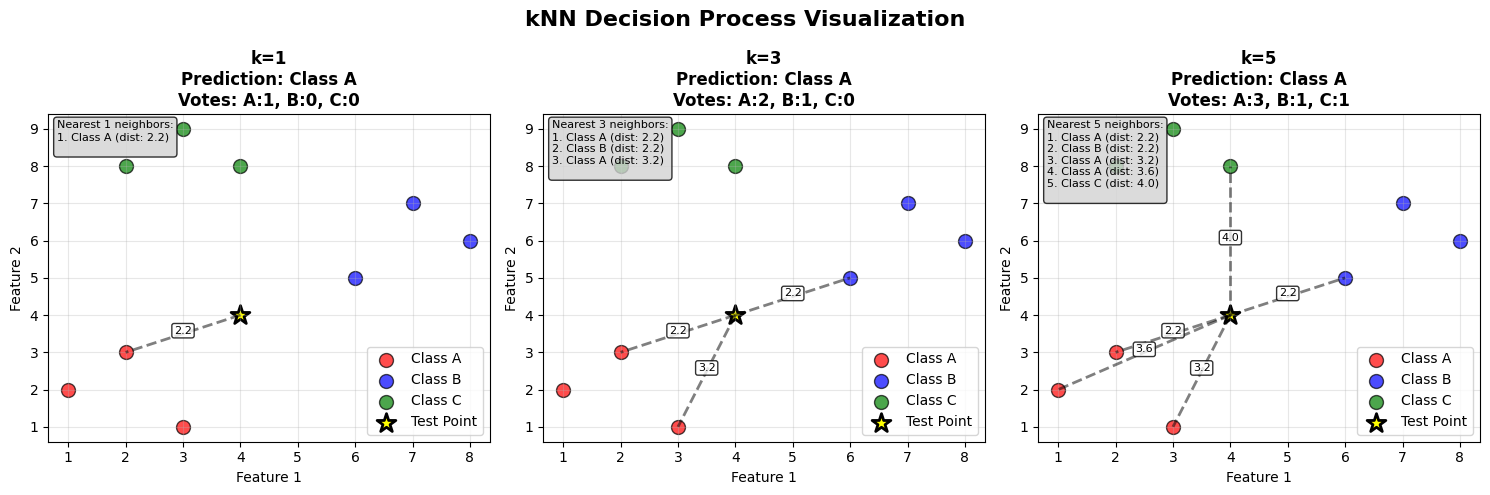

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_blobs
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

def comprehensive_knn_demo():
    """
    Complete kNN demonstration with multiple scenarios
    """
    # Create a 2D dataset for visualization
    X, y = make_blobs(n_samples=100, centers=3, n_features=2, 
                      random_state=42, cluster_std=2.5)
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('k-Nearest Neighbors: Complete Analysis', fontsize=16, fontweight='bold')
    
    # Test different k values
    k_values = [1, 3, 15]
    
    for i, k in enumerate(k_values):
        # Train kNN
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X, y)
        
        # Create decision boundary
        h = 0.1
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                            np.arange(y_min, y_max, h))
        
        mesh_points = np.c_[xx.ravel(), yy.ravel()]
        Z = knn.predict(mesh_points)
        Z = Z.reshape(xx.shape)
        
        # Plot decision boundary
        axes[0, i].contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.viridis)
        scatter = axes[0, i].scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.viridis, edgecolors='black')
        axes[0, i].set_title(f'k={k}\nDecision Boundaries', fontweight='bold')
        axes[0, i].set_xlabel('Feature 1')
        axes[0, i].set_ylabel('Feature 2')
        
        # Add interpretation
        if k == 1:
            axes[0, i].text(0.05, 0.95, 'Very detailed\nboundaries\n(may overfit)', 
                           transform=axes[0, i].transAxes, verticalalignment='top',
                           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        elif k == 3:
            axes[0, i].text(0.05, 0.95, 'Balanced\nboundaries\n(good choice)', 
                           transform=axes[0, i].transAxes, verticalalignment='top',
                           bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
        else:
            axes[0, i].text(0.05, 0.95, 'Smooth\nboundaries\n(may underfit)', 
                           transform=axes[0, i].transAxes, verticalalignment='top',
                           bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8))
    
    # Demonstrate the importance of feature scaling
    # Create data with different scales
    X_unscaled = np.array([[1, 1000], [2, 1001], [10, 1010], [11, 1011]])
    y_unscaled = np.array([0, 0, 1, 1])
    
    # Test point
    test_point = np.array([[1.5, 1005]])
    
    # Without scaling
    knn_unscaled = KNeighborsClassifier(n_neighbors=3)
    knn_unscaled.fit(X_unscaled, y_unscaled)
    distances_unscaled = []
    for point in X_unscaled:
        dist = np.sqrt((test_point[0, 0] - point[0])**2 + (test_point[0, 1] - point[1])**2)
        distances_unscaled.append(dist)
    
    # With scaling
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_unscaled)
    test_point_scaled = scaler.transform(test_point)
    
    knn_scaled = KNeighborsClassifier(n_neighbors=3)
    knn_scaled.fit(X_scaled, y_unscaled)
    distances_scaled = []
    for point in X_scaled:
        dist = np.sqrt((test_point_scaled[0, 0] - point[0])**2 + (test_point_scaled[0, 1] - point[1])**2)
        distances_scaled.append(dist)
    
    # Plot scaling comparison
    axes[1, 0].scatter(X_unscaled[:, 0], X_unscaled[:, 1], c=y_unscaled, s=100, cmap=plt.cm.viridis)
    axes[1, 0].scatter(test_point[0, 0], test_point[0, 1], c='red', s=200, marker='x', linewidth=3)
    axes[1, 0].set_title('Without Scaling\n(Feature 2 dominates)', fontweight='bold')
    axes[1, 0].set_xlabel('Feature 1 (small scale)')
    axes[1, 0].set_ylabel('Feature 2 (large scale)')
    
    axes[1, 1].scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_unscaled, s=100, cmap=plt.cm.viridis)
    axes[1, 1].scatter(test_point_scaled[0, 0], test_point_scaled[0, 1], c='red', s=200, marker='x', linewidth=3)
    axes[1, 1].set_title('With Scaling\n(Balanced influence)', fontweight='bold')
    axes[1, 1].set_xlabel('Feature 1 (standardized)')
    axes[1, 1].set_ylabel('Feature 2 (standardized)')
    
    # Performance comparison across different k values
    X_perf, y_perf = make_classification(n_samples=200, n_features=5, n_informative=3, 
                                        n_redundant=1, n_clusters_per_class=1, random_state=42)
    
    k_range = range(1, 31)
    cv_scores = []
    
    for k in k_range:
        knn_cv = KNeighborsClassifier(n_neighbors=k)
        scores = cross_val_score(knn_cv, X_perf, y_perf, cv=5, scoring='accuracy')
        cv_scores.append(scores.mean())
    
    axes[1, 2].plot(k_range, cv_scores, 'bo-', linewidth=2, markersize=6)
    axes[1, 2].set_title('Model Performance vs k\n(Cross-Validation)', fontweight='bold')
    axes[1, 2].set_xlabel('Number of Neighbors (k)')
    axes[1, 2].set_ylabel('Cross-Validation Accuracy')
    axes[1, 2].grid(True, alpha=0.3)
    
    # Highlight optimal k
    best_k = k_range[np.argmax(cv_scores)]
    best_score = max(cv_scores)
    axes[1, 2].scatter(best_k, best_score, color='red', s=100, zorder=5)
    axes[1, 2].annotate(f'Best k={best_k}\nScore={best_score:.3f}', 
                       xy=(best_k, best_score), xytext=(best_k+5, best_score-0.02),
                       arrowprops=dict(arrowstyle='->', color='red', lw=2),
                       fontweight='bold', color='red')
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed analysis
    print("🎯 k-NEAREST NEIGHBORS ANALYSIS")
    print("="*50)
    print(f"\n📊 SCALING IMPACT:")
    print(f"Without scaling - distances: {[f'{d:.2f}' for d in distances_unscaled]}")
    print(f"With scaling - distances: {[f'{d:.2f}' for d in distances_scaled]}")
    print(f"✅ Scaling ensures all features contribute equally!")
    
    print(f"\n🎯 OPTIMAL k VALUE:")
    print(f"Best k: {best_k}")
    print(f"Best cross-validation score: {best_score:.3f}")
    print(f"💡 Sweet spot balances bias and variance!")

def knn_neighbor_visualization():
    """
    Interactive visualization of how kNN makes decisions
    """
    # Create simple 2D dataset
    np.random.seed(42)
    X = np.array([[1, 2], [2, 3], [3, 1], [6, 5], [7, 7], [8, 6], [2, 8], [3, 9], [4, 8]])
    y = np.array([0, 0, 0, 1, 1, 1, 2, 2, 2])  # Three classes
    
    # Test point
    test_point = np.array([4, 4])
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('kNN Decision Process Visualization', fontsize=16, fontweight='bold')
    
    colors = ['red', 'blue', 'green']
    class_names = ['Class A', 'Class B', 'Class C']
    
    for i, k in enumerate([1, 3, 5]):
        # Calculate distances
        distances = []
        for j, point in enumerate(X):
            dist = np.sqrt((test_point[0] - point[0])**2 + (test_point[1] - point[1])**2)
            distances.append((dist, j, y[j]))
        
        # Sort by distance and get k nearest
        distances.sort(key=lambda x: x[0])
        k_nearest = distances[:k]
        
        # Plot all points
        for class_idx in range(3):
            class_points = X[y == class_idx]
            axes[i].scatter(class_points[:, 0], class_points[:, 1], 
                          c=colors[class_idx], label=class_names[class_idx], 
                          s=100, alpha=0.7, edgecolors='black')
        
        # Plot test point
        axes[i].scatter(test_point[0], test_point[1], c='yellow', s=200, 
                       marker='*', edgecolors='black', linewidth=2, label='Test Point')
        
        # Highlight k nearest neighbors
        for dist, idx, class_label in k_nearest:
            axes[i].plot([test_point[0], X[idx, 0]], [test_point[1], X[idx, 1]], 
                        'k--', alpha=0.5, linewidth=2)
            
            # Add distance annotation
            mid_x = (test_point[0] + X[idx, 0]) / 2
            mid_y = (test_point[1] + X[idx, 1]) / 2
            axes[i].annotate(f'{dist:.1f}', xy=(mid_x, mid_y), 
                           fontsize=8, ha='center',
                           bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))
        
        # Count votes
        votes = [0, 0, 0]
        for _, _, class_label in k_nearest:
            votes[class_label] += 1
        
        # Determine prediction
        predicted_class = np.argmax(votes)
        
        axes[i].set_title(f'k={k}\nPrediction: {class_names[predicted_class]}\n'
                         f'Votes: A:{votes[0]}, B:{votes[1]}, C:{votes[2]}', 
                         fontweight='bold')
        axes[i].set_xlabel('Feature 1')
        axes[i].set_ylabel('Feature 2')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
        
        # Add decision explanation
        explanation = f"Nearest {k} neighbors:\n"
        for j, (dist, idx, class_label) in enumerate(k_nearest):
            explanation += f"{j+1}. {class_names[class_label]} (dist: {dist:.1f})\n"
        
        axes[i].text(0.02, 0.98, explanation, transform=axes[i].transAxes, 
                    verticalalignment='top', fontsize=8,
                    bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

# Run the comprehensive demonstrations
comprehensive_knn_demo()
print("\n" + "="*70)
knn_neighbor_visualization()

---
## 6. 🏔️ Gradient Descent - Complete Journey Guide

### **The Core Concept: "Finding the Valley Bottom"**

**Philosophy:** If you're lost on a mountain in fog and want to find the lowest point, what do you do?
- **Step 1:** Feel the slope around you
- **Step 2:** Take a step in the steepest downward direction  
- **Step 3:** Repeat until you can't go any lower
- **Goal:** Find the minimum point (best parameters for your model)

### **Multiple Powerful Analogies:**

#### **🏔️ Mountain Climbing (Extended):**
**Scenario:** You're blindfolded on a mountain, trying to reach the valley

**Your position:** Current parameter values (θ)
**Elevation:** Cost/Loss function value
**Slope feeling:** Gradient (derivative)
**Step size:** Learning rate (α)

**Process:**
1. **Feel around** → Calculate gradient
2. **Determine steepest descent** → Negative gradient direction  
3. **Take a step** → Update parameters: θ = θ - α × gradient
4. **Check new position** → Evaluate new cost
5. **Repeat** until you reach the bottom

**Challenges:**
- **Too big steps:** Might overshoot the valley (high learning rate)
- **Too small steps:** Takes forever to reach bottom (low learning rate)
- **False valleys:** Local minima vs global minimum
- **Plateau:** Flat areas where progress is slow

#### **🎯 Archer Learning to Hit Bullseye:**
**Goal:** Minimize distance from bullseye (minimize loss)

**Current shot:** Your model's current prediction
**Miss distance:** Error/loss function
**Adjustment direction:** Negative gradient
**Adjustment size:** Learning rate

**Learning process:**
1. **Shoot arrow** → Make prediction
2. **See where it landed** → Calculate loss
3. **Adjust aim** → Update weights based on gradient
4. **Try again** → Next iteration
5. **Repeat** until hitting bullseye consistently

**Learning rate effects:**
- **High learning rate:** Big adjustments (might overcorrect)
- **Low learning rate:** Small adjustments (slow but steady)
- **Adaptive:** Start big, get smaller as you improve

#### **🎮 Video Game Score Optimization:**
**Goal:** Maximize game score by adjusting strategy parameters

**Current strategy:** Parameter values
**Score:** Negative loss (we minimize loss = maximize score)
**Strategy adjustment:** Parameter updates
**Game feedback:** Gradient information

### **The Mathematics Made Simple:**

#### **The Gradient: Your Direction Compass**
**Mathematical definition:** ∇f = [∂f/∂θ₁, ∂f/∂θ₂, ..., ∂f/∂θₙ]

**Practical interpretation:**
- **Gradient points uphill** → Steepest increase direction
- **Negative gradient points downhill** → Steepest decrease direction
- **Magnitude tells steepness** → How fast function changes
- **Zero gradient = flat area** → Potential minimum/maximum

#### **The Update Rule:**
**Formula:** θ_new = θ_old - α × ∇f(θ_old)

**Breaking it down:**
- **θ_old:** Where you are now
- **α (alpha):** Learning rate (step size)
- **∇f(θ_old):** Gradient at current position
- **α × ∇f(θ_old):** How much to move
- **Minus sign:** Move opposite to gradient (downhill)

### **Learning Rate: The Critical Hyperparameter**

#### **Too High Learning Rate (α >> optimal):**
**Problems:**
- **Oscillation:** Bounce back and forth across minimum
- **Divergence:** Get worse instead of better
- **Instability:** Never converge to solution

**Visual:** Like a ball bouncing too hard in a bowl - never settles

**Signs:**
- Loss increases or oscillates wildly
- Parameters explode to very large values
- Model performance gets worse over time

#### **Too Low Learning Rate (α << optimal):**
**Problems:**
- **Slow convergence:** Takes forever to reach minimum
- **Stuck in plateaus:** Can't escape flat regions
- **Premature stopping:** Give up before reaching optimum

**Visual:** Like an ant crawling down a mountain - technically moving but painfully slow

**Signs:**
- Loss decreases very slowly
- Training takes extremely long
- Improvement plateaus early

#### **Just Right Learning Rate:**
**Characteristics:**
- **Steady decrease** in loss function
- **Reasonable convergence time** (minutes to hours, not days)
- **Stable final performance**
- **Smooth learning curves**

**Finding the sweet spot:**
- **Start with 0.01** (common default)
- **Learning rate schedules:** Start high, decrease over time
- **Adaptive methods:** Adam, RMSprop automatically adjust
- **Grid search:** Try multiple values and compare

### **Types of Gradient Descent:**

#### **1. Batch Gradient Descent (Full Dataset):**
**Process:**
- Use **entire dataset** to calculate gradient
- Update parameters **once per epoch**
- **Accurate** gradient estimation

**Advantages:**
- **Stable convergence** - smooth path to minimum
- **Guaranteed convergence** for convex functions
- **Efficient** for small datasets

**Disadvantages:**
- **Slow for large datasets** - must process all data
- **Memory intensive** - need entire dataset in memory
- **No online learning** - can't update with new data

**When to use:** Small to medium datasets, when accuracy is crucial

#### **2. Stochastic Gradient Descent (One Sample at a Time):**
**Process:**
- Use **single random sample** to calculate gradient
- Update parameters **after each sample**
- **Noisy** but fast gradient estimation

**Advantages:**
- **Fast updates** - immediate learning from each sample
- **Online learning** - can handle streaming data
- **Escape local minima** - noise helps jump out of traps
- **Memory efficient** - process one sample at a time

**Disadvantages:**
- **Noisy convergence** - zigzag path to minimum
- **May not converge** exactly to minimum
- **Sensitive to learning rate** - harder to tune

**When to use:** Large datasets, online learning, need fast updates

#### **3. Mini-Batch Gradient Descent (Best of Both Worlds):**
**Process:**
- Use **small batch** (32, 64, 128 samples) to calculate gradient
- Update parameters **after each mini-batch**
- **Balance** between accuracy and speed

**Advantages:**
- **Good convergence** - more stable than SGD
- **Efficient computation** - vectorized operations
- **Manageable memory** - process reasonable chunks
- **Parallel processing** - can use GPU effectively

**Disadvantages:**
- **Extra hyperparameter** - batch size to tune
- **Still some noise** - not as smooth as batch GD

**When to use:** Most practical applications - default choice

### **Advanced Gradient Descent Variants:**

#### **Momentum (Adding Velocity):**
**Analogy:** Ball rolling down hill builds momentum

**Formula:** 
- v = β × v_previous + α × gradient
- θ = θ - v

**Benefits:**
- **Faster convergence** in consistent directions
- **Dampens oscillations** in inconsistent directions
- **Escapes local minima** better

#### **Adam Optimizer (Adaptive Moments):**
**Combines:** Momentum + adaptive learning rates
**Features:**
- **Individual learning rates** for each parameter
- **Bias correction** for first moments
- **Usually works well** out of the box

**Default choice** for many deep learning applications

### **Common Problems and Solutions:**

#### **Problem 1: Saddle Points**
**Issue:** Gradient is zero but not at minimum (like a mountain pass)
**Solution:** Momentum helps escape, noise in SGD helps

#### **Problem 2: Local Minima**
**Issue:** Stuck in suboptimal solution
**Solutions:** 
- Random restarts
- Simulated annealing
- Different initialization
- Add noise (SGD naturally has this)

#### **Problem 3: Vanishing/Exploding Gradients**
**Vanishing:** Gradients become too small (common in deep networks)
**Exploding:** Gradients become too large
**Solutions:**
- Gradient clipping
- Proper weight initialization
- Batch normalization
- Residual connections

#### **Problem 4: Plateau (Flat Loss Landscape)**
**Issue:** Gradient near zero, progress extremely slow
**Solutions:**
- Learning rate scheduling
- Momentum methods
- Adaptive optimizers
- Feature engineering

### **Practical Implementation Tips:**

#### **Monitoring Training:**
**Plot loss curves:**
- **Training loss should decrease** consistently
- **Validation loss should track training** (with slight lag)
- **Gap between them indicates overfitting**

**Watch for patterns:**
- **Smooth decrease:** Good learning rate
- **Oscillating:** Learning rate too high
- **Plateauing:** Need different approach or patience
- **Increasing:** Major problem (wrong direction, exploding gradients)

#### **Early Stopping:**
**Strategy:** Stop training when validation loss stops improving
**Benefits:** Prevents overfitting, saves time
**Implementation:** Track best validation loss, stop after N epochs without improvement

#### **Learning Rate Scheduling:**
**Step decay:** Reduce learning rate by factor every N epochs
**Exponential decay:** Gradually reduce learning rate
**Cosine annealing:** Smooth reduction with restarts
**Adaptive:** Let optimizer handle it (Adam, RMSprop)

### **Real-World Applications:**

#### **Neural Networks:**
- **Backpropagation** is gradient descent through the network
- **Each layer** has parameters updated via gradient descent
- **Deep learning success** heavily relies on efficient gradient descent

#### **Linear/Logistic Regression:**
- **Closed-form solutions** exist but gradient descent still useful
- **Large datasets** where matrix inversion is expensive
- **Online learning** scenarios

#### **Recommendation Systems:**
- **Matrix factorization** for collaborative filtering
- **Embedding learning** for user/item representations

#### **Hyperparameter Optimization:**
- **Neural architecture search**
- **Automated machine learning**
- **Meta-learning** algorithms

ValueError: 'greeno-' is not a valid format string (two color symbols)

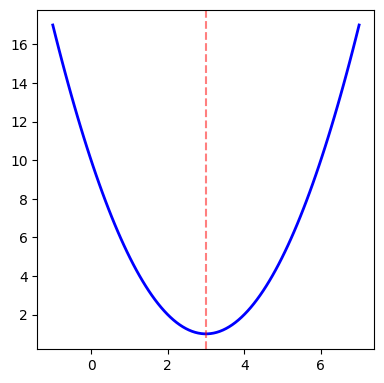

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def comprehensive_gradient_descent_demo():
    """
    Complete gradient descent visualization with multiple scenarios
    """
    fig = plt.figure(figsize=(20, 15))
    
    # 1. Simple 1D function to show basic concept
    def simple_function(x):
        return (x - 3)**2 + 1
    
    def simple_derivative(x):
        return 2 * (x - 3)
    
    # Gradient descent on 1D function
    x_range = np.linspace(-1, 7, 100)
    y_range = simple_function(x_range)
    
    # Different learning rates
    learning_rates = [0.1, 0.3, 0.8]
    starting_point = 6.5
    
    ax1 = plt.subplot(3, 4, 1)
    plt.plot(x_range, y_range, 'b-', linewidth=2, label='f(x) = (x-3)² + 1')
    plt.axvline(x=3, color='red', linestyle='--', alpha=0.5, label='True minimum')
    
    colors = ['green', 'orange', 'red']
    for i, lr in enumerate(learning_rates):
        x_current = starting_point
        x_path = [x_current]
        y_path = [simple_function(x_current)]
        
        for _ in range(10):
            gradient = simple_derivative(x_current)
            x_current = x_current - lr * gradient
            x_path.append(x_current)
            y_path.append(simple_function(x_current))
        
        plt.plot(x_path, y_path, f'{colors[i]}o-', alpha=0.7, 
                label=f'α={lr}', markersize=4)
    
    plt.title('Gradient Descent with Different Learning Rates', fontweight='bold')
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 2. 2D function with contour plot
    def rosenbrock(x, y):
        return (1 - x)**2 + 100 * (y - x**2)**2
    
    def rosenbrock_gradient(x, y):
        dx = -2 * (1 - x) - 400 * x * (y - x**2)
        dy = 200 * (y - x**2)
        return np.array([dx, dy])
    
    ax2 = plt.subplot(3, 4, 2)
    x_2d = np.linspace(-2, 2, 100)
    y_2d = np.linspace(-1, 3, 100)
    X_2d, Y_2d = np.meshgrid(x_2d, y_2d)
    Z_2d = rosenbrock(X_2d, Y_2d)
    
    contour = plt.contour(X_2d, Y_2d, Z_2d, levels=50, alpha=0.6)
    plt.colorbar(contour, ax=ax2, shrink=0.8)
    
    # Gradient descent path
    position = np.array([-1.5, 2.5])
    path = [position.copy()]
    lr = 0.001
    
    for i in range(1000):
        grad = rosenbrock_gradient(position[0], position[1])
        position = position - lr * grad
        if i % 50 == 0:  # Record every 50th step
            path.append(position.copy())
    
    path = np.array(path)
    plt.plot(path[:, 0], path[:, 1], 'r.-', markersize=6, linewidth=2, 
             label='GD Path')
    plt.plot(1, 1, 'g*', markersize=15, label='Global Minimum')
    plt.title('2D Optimization: Rosenbrock Function', fontweight='bold')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    
    # 3. Learning rate comparison
    ax3 = plt.subplot(3, 4, 3)
    
    def quadratic_loss(theta):
        return 0.5 * (theta - 2)**2
    
    def quadratic_gradient(theta):
        return theta - 2
    
    learning_rates_detailed = [0.1, 0.5, 1.0, 1.5]
    iterations = 15
    
    for lr in learning_rates_detailed:
        theta = 5.0  # Starting point
        loss_history = []
        
        for i in range(iterations):
            loss = quadratic_loss(theta)
            loss_history.append(loss)
            gradient = quadratic_gradient(theta)
            theta = theta - lr * gradient
        
        plt.plot(loss_history, 'o-', label=f'α={lr}', linewidth=2, markersize=4)
    
    plt.title('Learning Rate Impact on Convergence', fontweight='bold')
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    
    # 4. Batch vs Stochastic vs Mini-batch
    ax4 = plt.subplot(3, 4, 4)
    
    np.random.seed(42)
    # Simulate different gradient descent types
    true_minimum = 0
    iterations = 100
    
    # Batch GD (smooth)
    batch_loss = []
    current_loss = 10
    for i in range(iterations):
        batch_loss.append(current_loss)
        current_loss = current_loss * 0.95  # Smooth decrease
    
    # SGD (noisy)
    sgd_loss = []
    current_loss = 10
    for i in range(iterations):
        noise = np.random.normal(0, 0.5)
        current_loss = current_loss * 0.95 + noise
        sgd_loss.append(max(0, current_loss))
    
    # Mini-batch (balanced)
    minibatch_loss = []
    current_loss = 10
    for i in range(iterations):
        noise = np.random.normal(0, 0.2)
        current_loss = current_loss * 0.95 + noise
        minibatch_loss.append(max(0, current_loss))
    
    plt.plot(batch_loss, 'b-', linewidth=2, label='Batch GD')
    plt.plot(sgd_loss, 'r-', alpha=0.7, linewidth=1, label='Stochastic GD')
    plt.plot(minibatch_loss, 'g-', linewidth=2, label='Mini-batch GD')
    
    plt.title('Different Types of Gradient Descent', fontweight='bold')
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 5-8. Four more detailed visualizations
    
    # 5. Momentum visualization
    ax5 = plt.subplot(3, 4, 5)
    
    def momentum_vs_normal():
        # Normal GD
        x_normal = 4.0
        x_path_normal = [x_normal]
        lr = 0.1
        
        for _ in range(20):
            grad = simple_derivative(x_normal)
            x_normal = x_normal - lr * grad
            x_path_normal.append(x_normal)
        
        # GD with momentum
        x_momentum = 4.0
        velocity = 0
        x_path_momentum = [x_momentum]
        momentum_coef = 0.9
        
        for _ in range(20):
            grad = simple_derivative(x_momentum)
            velocity = momentum_coef * velocity + lr * grad
            x_momentum = x_momentum - velocity
            x_path_momentum.append(x_momentum)
        
        return x_path_normal, x_path_momentum
    
    x_normal, x_momentum = momentum_vs_normal()
    
    plt.plot(x_range, y_range, 'b-', linewidth=2, alpha=0.3)
    plt.plot(x_normal, [simple_function(x) for x in x_normal], 
             'ro-', label='Normal GD', markersize=4)
    plt.plot(x_momentum, [simple_function(x) for x in x_momentum], 
             'go-', label='GD + Momentum', markersize=4)
    plt.axvline(x=3, color='red', linestyle='--', alpha=0.5)
    
    plt.title('Gradient Descent with Momentum', fontweight='bold')
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 6. Local minima problem
    ax6 = plt.subplot(3, 4, 6)
    
    def multi_modal_function(x):
        return 0.1 * x**4 - 0.5 * x**3 - 2 * x**2 + 3 * x + 1
    
    def multi_modal_derivative(x):
        return 0.4 * x**3 - 1.5 * x**2 - 4 * x + 3
    
    x_multi = np.linspace(-4, 6, 1000)
    y_multi = multi_modal_function(x_multi)
    
    plt.plot(x_multi, y_multi, 'b-', linewidth=2)
    
    # Different starting points
    starting_points = [-3, 0, 4]
    colors = ['red', 'green', 'orange']
    
    for i, start in enumerate(starting_points):
        x_current = start
        x_path = [x_current]
        y_path = [multi_modal_function(x_current)]
        
        for _ in range(50):
            grad = multi_modal_derivative(x_current)
            if abs(grad) < 0.01:  # Stop if gradient is small
                break
            x_current = x_current - 0.01 * grad
            x_path.append(x_current)
            y_path.append(multi_modal_function(x_current))
        
        plt.plot(x_path, y_path, f'{colors[i]}o-', alpha=0.8, 
                label=f'Start: {start}', markersize=3)
    
    plt.title('Local Minima Problem', fontweight='bold')
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 7. Learning rate scheduling
    ax7 = plt.subplot(3, 4, 7)
    
    epochs = 100
    
    # Constant learning rate
    lr_constant = [0.1] * epochs
    
    # Step decay
    lr_step = []
    for epoch in range(epochs):
        if epoch < 30:
            lr_step.append(0.1)
        elif epoch < 60:
            lr_step.append(0.05)
        else:
            lr_step.append(0.01)
    
    # Exponential decay
    lr_exp = [0.1 * (0.96 ** epoch) for epoch in range(epochs)]
    
    # Cosine annealing
    lr_cosine = [0.05 + 0.05 * (1 + np.cos(np.pi * epoch / epochs)) for epoch in range(epochs)]
    
    plt.plot(lr_constant, 'b-', linewidth=2, label='Constant')
    plt.plot(lr_step, 'r-', linewidth=2, label='Step Decay')
    plt.plot(lr_exp, 'g-', linewidth=2, label='Exponential')
    plt.plot(lr_cosine, 'm-', linewidth=2, label='Cosine Annealing')
    
    plt.title('Learning Rate Scheduling', fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 8. Optimization landscape
    ax8 = plt.subplot(3, 4, 8)
    
    def optimization_landscape(x, y):
        return (x**2 + y**2) + 0.1 * np.sin(10*x) * np.cos(10*y)
    
    x_opt = np.linspace(-2, 2, 100)
    y_opt = np.linspace(-2, 2, 100)
    X_opt, Y_opt = np.meshgrid(x_opt, y_opt)
    Z_opt = optimization_landscape(X_opt, Y_opt)
    
    contour = plt.contourf(X_opt, Y_opt, Z_opt, levels=30, cmap='viridis', alpha=0.7)
    plt.colorbar(contour, ax=ax8, shrink=0.8)
    
    # Show multiple paths from different starting points
    start_points = [[-1.5, -1.5], [1.5, -1.5], [-1.5, 1.5], [1.5, 1.5]]
    
    for i, start in enumerate(start_points):
        # Simulate gradient descent path (simplified)
        path_x = [start[0]]
        path_y = [start[1]]
        
        current_x, current_y = start
        lr = 0.1
        
        for _ in range(20):
            # Approximate gradient
            grad_x = 2 * current_x + np.cos(10 * current_x) * (-np.sin(10 * current_y))
            grad_y = 2 * current_y + np.sin(10 * current_x) * np.sin(10 * current_y)
            
            current_x = current_x - lr * grad_x
            current_y = current_y - lr * grad_y
            
            path_x.append(current_x)
            path_y.append(current_y)
            
            if abs(grad_x) < 0.01 and abs(grad_y) < 0.01:
                break
        
        plt.plot(path_x, path_y, 'r-', linewidth=2, alpha=0.8)
        plt.plot(start[0], start[1], 'ro', markersize=8)
        plt.plot(path_x[-1], path_y[-1], 'r*', markersize=10)
    
    plt.title('Complex Optimization Landscape', fontweight='bold')
    plt.xlabel('x')
    plt.ylabel('y')
    
    plt.tight_layout()
    plt.show()
    
    # Print analysis
    print("🏔️ GRADIENT DESCENT ANALYSIS")
    print("="*50)
    print("\n📈 KEY INSIGHTS:")
    print("• Learning rate α controls step size")
    print("• Too high α → oscillation/divergence")
    print("• Too low α → slow convergence")
    print("• Momentum helps escape local minima")
    print("• Different GD types suit different scenarios")
    print("• Learning rate scheduling improves performance")
    print("\n🎯 PRACTICAL GUIDELINES:")
    print("• Start with α = 0.01-0.1")
    print("• Use mini-batch GD for most problems")
    print("• Consider Adam optimizer for deep learning")
    print("• Monitor loss curves to detect issues")
    print("• Use early stopping to prevent overfitting")

def gradient_descent_step_by_step():
    """
    Step-by-step gradient descent visualization
    """
    print("🔍 STEP-BY-STEP GRADIENT DESCENT")
    print("="*40)
    
    # Define function and its derivative
    def f(x):
        return (x - 2)**2 + 1
    
    def df_dx(x):
        return 2 * (x - 2)
    
    # Initial setup
    x_current = 5.0
    learning_rate = 0.3
    iterations = 8
    
    print(f"📋 SETUP:")
    print(f"Function: f(x) = (x-2)² + 1")
    print(f"Starting point: x = {x_current}")
    print(f"Learning rate: α = {learning_rate}")
    print(f"Target: minimum at x = 2\n")
    
    # Track progress
    x_history = [x_current]
    f_history = [f(x_current)]
    
    for i in range(iterations):
        # Calculate gradient
        gradient = df_dx(x_current)
        
        # Calculate new position
        x_new = x_current - learning_rate * gradient
        
        print(f"🔄 ITERATION {i+1}:")
        print(f"Current position: x = {x_current:.3f}")
        print(f"Function value: f(x) = {f(x_current):.3f}")
        print(f"Gradient: f'(x) = {gradient:.3f}")
        print(f"Update: x_new = {x_current:.3f} - {learning_rate} × {gradient:.3f} = {x_new:.3f}")
        print(f"Distance to minimum: {abs(x_new - 2):.3f}")
        print("-" * 40)
        
        # Update for next iteration
        x_current = x_new
        x_history.append(x_current)
        f_history.append(f(x_current))
    
    print(f"🎯 FINAL RESULT:")
    print(f"Final position: x = {x_current:.3f}")
    print(f"Final function value: f(x) = {f(x_current):.3f}")
    print(f"True minimum: f(2) = 1")
    print(f"Error: {f(x_current) - 1:.6f}")

# Run the demonstrations
comprehensive_gradient_descent_demo()
print("\n" + "="*70)
gradient_descent_step_by_step()

---
## 7. 🎯 Matriz de Confusão - O Boletim do Seu Modelo

### **O Conceito Central: "Matriz Verdade vs Predição"**

**Filosofia:** Uma matriz de confusão é como um boletim detalhado mostrando exatamente onde seu modelo tem sucesso e falha
- **Linhas:** O que realmente aconteceu (Rótulos verdadeiros)
- **Colunas:** O que seu modelo previu (Rótulos previstos)
- **Objetivo:** Entender padrões nos erros do modelo
- **Poder:** Vai além da precisão simples para mostrar desempenho detalhado

### **Múltiplas Analogias Claras:**

#### **🏥 Relatório de Diagnóstico Médico:**
**Cenário:** Testando pacientes para uma doença

```
                    PREVISTO
                 Doença  Saudável
REAL    Doença     85       15     ← 100 pacientes doentes
       Saudável    10      890     ← 900 pacientes saudáveis
```

**Lendo a matriz:**
- **85 pacientes:** Diagnosticados corretamente como doentes ✅
- **15 pacientes:** Doentes mas diagnosticados como saudáveis ❌ (Perigoso!)
- **10 pacientes:** Saudáveis mas diagnosticados como doentes ❌ (Alarme falso)
- **890 pacientes:** Diagnosticados corretamente como saudáveis ✅

#### **🎬 Sistema de Recomendação de Filmes:**
**Cenário:** Prevendo se usuários vão gostar de um filme

```
                    PREVISTO
                  Gosta  Não Gosta
REAL      Gosta    450     50     ← 500 usuários que realmente gostaram
       Não Gosta   30    470     ← 500 usuários que realmente não gostaram
```

**Interpretação:**
- **450:** Previsto corretamente "gosta" ✅
- **50:** Usuários gostaram mas previmos "não gosta" ❌ (Oportunidade perdida)
- **30:** Usuários não gostaram mas previmos "gosta" ❌ (Recomendação ruim)
- **470:** Previsto corretamente "não gosta" ✅

#### **🎓 Predição de Aprovação em Exame:**
**Cenário:** Prevendo se estudantes vão passar baseado em horas de estudo

```
                    PREVISTO
                  Passa  Reprova
REAL      Passa    180     20     ← 200 estudantes que realmente passaram
       Reprova      15    185     ← 200 estudantes que realmente reprovaram
```

### **Os Quatro Números Sagrados:**

#### **Verdadeiros Positivos (TP) - Os Heróis 🦸‍♀️**
**Definição:** Modelo previu corretamente a classe positiva
**Exemplo médico:** Pacientes doentes identificados corretamente
**Impacto comercial:** Encontrou os clientes que vão comprar
**Símbolo:** Célula superior esquerda na classificação binária
**Objetivo:** Maximizar esses (mas não à custa de falsos positivos)

#### **Falsos Positivos (FP) - Os Alarmes Falsos 🚨**
**Definição:** Modelo previu incorretamente a classe positiva
**Exemplo médico:** Pacientes saudáveis diagnosticados como doentes
**Impacto comercial:** Direcionou não-compradores com anúncios (desperdício de dinheiro)
**Símbolo:** Celula superior direita na classificação binária
**Problema:** Erro Tipo I - dizer "sim" quando a resposta é "não"

#### **Falsos Negativos (FN) - As Oportunidades Perdidas 😞**
**Definição:** Modelo previu incorretamente a classe negativa
**Exemplo médico:** Pacientes doentes diagnosticados como saudáveis
**Impacto comercial:** Perdeu clientes potenciais
**Símbolo:** Celula inferior esquerda na classificação binária
**Problema:** Erro Tipo II - dizer "não" quando a resposta é "sim"

#### **Verdadeiros Negativos (TN) - As Rejeições Corretas ✋**
**Definição:** Modelo previu corretamente a classe negativa
**Exemplo médico:** Pacientes saudáveis identificados corretamente
**Impacto comercial:** Identificou corretamente não-compradores
**Símbolo:** Celula inferior direita na classificação binária
**Objetivo:** Maximizar esses (mas não ignorar a classe positiva)

### **Métricas Principais Derivadas da Matriz de Confusão:**

#### **Acurácia = (TP + TN) / (TP + TN + FP + FN)**
**Significado:** Correção geral
**Quando útil:** Classes balanceadas, custos iguais de classificação incorreta
**Quando enganosa:** Classes desbalanceadas
**Exemplo:** 95% de acurácia parece ótimo, mas se 95% dos emails não são spam, apenas prever "não spam" para tudo resulta em 95% de acurácia!

#### **Precisão = TP / (TP + FP)**
**Significado:** De todas as predições positivas, quantas estavam corretas?
**Pergunta:** "Quando prevejo positivo, com que frequência estou certo?"
**Médico:** Dos pacientes diagnosticados como doentes, que porcentagem realmente está doente?
**Filtro de spam:** Dos emails marcados como spam, que porcentagem realmente é spam?
**Precisão alta significa:** Taxa baixa de falsos positivos

#### **Recall (Sensibilidade) = TP / (TP + FN)**
**Significado:** De todos os positivos reais, quantos encontramos?
**Pergunta:** "De todos os casos positivos, quantos eu capturei?"
**Médico:** De todos os pacientes doentes, que porcentagem diagnosticamos?
**Detecção de fraude:** De todas as transações fraudulentas, que porcentagem capturamos?
**Recall alto significa:** Taxa baixa de falsos negativos

#### **Especificidade = TN / (TN + FP)**
**Significado:** De todos os negativos reais, quantos identificamos corretamente?
**Pergunta:** "De todos os casos negativos, quantos rejeitei corretamente?"
**Médico:** De todos os pacientes saudáveis, que porcentagem identificamos corretamente como saudáveis?
**Complementary to Recall:** Recall focuses on positives, Specificity on negatives

#### **F1 Score = 2 × (Precision × Recall) / (Precision + Recall)**
**Meaning:** Harmonic mean of Precision and Recall
**When useful:** Want balance between Precision and Recall
**Why harmonic mean:** Penalizes extreme values (if either Precision or Recall is low, F1 is low)

### **The Precision-Recall Trade-off:**

#### **High Precision, Low Recall Strategy:**
**Approach:** Very strict positive predictions
**Medical:** Only diagnose disease with 99% confidence
**Result:**
- **Few false positives** (don't alarm healthy people)
- **Many false negatives** (miss some sick patients)
- **Use when:** False positives are very costly

#### **High Recall, Low Precision Strategy:**
**Approach:** Liberal positive predictions
**Medical:** Diagnose disease with 60% confidence
**Result:**
- **Few false negatives** (catch most sick patients)
- **Many false positives** (alarm some healthy people)
- **Use when:** False negatives are very costly

#### **Balanced Strategy:**
**Approach:** Optimize F1 score
**Result:** Reasonable performance on both metrics
**Use when:** Both errors have similar costs

### **Multi-Class Confusion Matrices:**

#### **3x3 Example: Iris Flower Classification**
```
                    PREDICTED
                Setosa Versicolor Virginica
ACTUAL  Setosa     50      0         0
    Versicolor      0     47         3
     Virginica      0      2        48
```

**Reading the matrix:**
- **Perfect on Setosa:** All 50 correctly classified
- **Versicolor confusion:** 3 misclassified as Virginica
- **Virginica confusion:** 2 misclassified as Versicolor
- **Overall pattern:** Model confuses Versicolor and Virginica (they're similar species)

#### **Per-Class Metrics:**
For each class, calculate:
- **Precision:** How many predictions for this class were correct?
- **Recall:** How many actual instances of this class were found?
- **F1 Score:** Balance between precision and recall for this class

**Macro Average:** Average metrics across all classes (treats all classes equally)
**Weighted Average:** Average metrics weighted by class frequency (accounts for class imbalance)

### **Common Confusion Matrix Patterns:**

#### **Pattern 1: Random Classifier**
```
                PREDICTED
              0     1
ACTUAL    0  50    50    ← 50% accuracy per class
          1  50    50
```
**Characteristics:** Diagonal not much higher than off-diagonal
**Problem:** Model isn't learning meaningful patterns

#### **Pattern 2: Biased Classifier**
```
                PREDICTED
              0     1
ACTUAL    0  95     5    ← Very good at class 0
          1  80    20    ← Very poor at class 1
```
**Characteristics:** Good performance on majority class, poor on minority
**Problem:** Model biased toward majority class

#### **Pattern 3: Conservative Classifier**
```
                PREDICTED
              0     1
ACTUAL    0  90    10    ← High specificity
          1  30    70    ← Lower sensitivity
```
**Characteristics:** Avoids false positives but misses true positives
**Use case:** When false positives are very costly

#### **Pattern 4: Liberal Classifier**
```
                PREDICTED
              0     1
ACTUAL    0  70    30    ← Lower specificity
          1  10    90    ← High sensitivity
```
**Characteristics:** Catches most positives but creates false alarms
**Use case:** When false negatives are very costly

### **Industry-Specific Interpretations:**

#### **Fraud Detection:**
**False Positive:** Block legitimate transaction
**False Negative:** Allow fraudulent transaction
**Usually prefer:** High recall (catch fraud) even with some false positives
**Cost consideration:** Lost money from fraud > customer inconvenience

#### **Email Spam Filter:**
**False Positive:** Important email marked as spam
**False Negative:** Spam email reaches inbox
**Usually prefer:** High precision (don't hide important emails)
**User tolerance:** Missing some spam acceptable, losing important emails is not

#### **Cancer Screening:**
**False Positive:** Unnecessary worry, additional tests
**False Negative:** Missed cancer diagnosis
**Usually prefer:** High recall (catch all cancer cases)
**Life consideration:** Additional tests acceptable, missed cancer is catastrophic

#### **Recommendation System:**
**False Positive:** Recommend item user won't like
**False Negative:** Don't recommend item user would like
**Balance needed:** Both hurt user experience and business metrics

### **Improving Based on Confusion Matrix:**

#### **High False Positives:**
**Solutions:**
- Increase decision threshold
- Add more negative training examples
- Feature engineering to better distinguish classes
- Use cost-sensitive learning

#### **High False Negatives:**
**Solutions:**
- Decrease decision threshold
- Add more positive training examples
- Address class imbalance (SMOTE, oversampling)
- Ensemble methods

#### **Overall Low Performance:**
**Solutions:**
- Collect more/better training data
- Feature engineering
- Try different algorithms
- Hyperparameter tuning
- Check for data quality issues

### **Advanced Confusion Matrix Analysis:**

#### **Class Confusion Analysis:**
**Question:** Which classes are most commonly confused?
**Method:** Look at largest off-diagonal elements
**Action:** 
- Collect more distinguishing features
- Get more training data for confused classes
- Consider merging very similar classes

#### **Error Distribution Analysis:**
**Question:** Are errors random or systematic?
**Method:** Analyze patterns in misclassifications
**Insights:**
- Systematic errors → Model bias or missing features
- Random errors → Need more data or capacity

#### **Threshold Optimization:**
**For binary classification:** Plot Precision-Recall curve
**Find optimal threshold** that balances precision and recall for your use case
**Use business metrics** to determine optimal trade-off point

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

def comprehensive_confusion_matrix_demo():
    """
    Complete confusion matrix demonstration with multiple scenarios
    """
    # Generate sample data
    X, y = make_classification(n_samples=1000, n_features=20, n_informative=10,
                              n_redundant=10, n_classes=3, random_state=42)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    # Train a classifier
    clf = RandomForestClassifier(random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    # Create confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Confusion Matrix: Complete Analysis Guide', fontsize=16, fontweight='bold')
    
    # 1. Basic confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0])
    axes[0, 0].set_title('3-Class Confusion Matrix', fontweight='bold')
    axes[0, 0].set_xlabel('Predicted Class')
    axes[0, 0].set_ylabel('Actual Class')
    
    # Add detailed annotations
    total_samples = np.sum(cm)
    accuracy = np.trace(cm) / total_samples
    axes[0, 0].text(0.5, -0.15, f'Overall Accuracy: {accuracy:.3f}', 
                   transform=axes[0, 0].transAxes, ha='center', fontweight='bold')
    
    # 2. Normalized confusion matrix (percentages)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Greens', ax=axes[0, 1])
    axes[0, 1].set_title('Normalized Confusion Matrix\n(Row percentages)', fontweight='bold')
    axes[0, 1].set_xlabel('Predicted Class')
    axes[0, 1].set_ylabel('Actual Class')
    
    # 3. Binary classification example with detailed metrics
    # Create binary version (class 0 vs rest)
    y_binary_true = (y_test == 0).astype(int)
    y_binary_pred = (y_pred == 0).astype(int)
    cm_binary = confusion_matrix(y_binary_true, y_binary_pred)
    
    # Extract values
    tn, fp, fn, tp = cm_binary.ravel()
    
    # Create annotated binary confusion matrix
    axes[0, 2].imshow([[tp, fn], [fp, tn]], cmap='RdYlBu', alpha=0.7)
    
    # Add labels and values
    axes[0, 2].text(0, 0, f'TP\n{tp}', ha='center', va='center', fontsize=14, fontweight='bold')
    axes[0, 2].text(1, 0, f'FN\n{fn}', ha='center', va='center', fontsize=14, fontweight='bold')
    axes[0, 2].text(0, 1, f'FP\n{fp}', ha='center', va='center', fontsize=14, fontweight='bold')
    axes[0, 2].text(1, 1, f'TN\n{tn}', ha='center', va='center', fontsize=14, fontweight='bold')
    
    axes[0, 2].set_xticks([0, 1])
    axes[0, 2].set_yticks([0, 1])
    axes[0, 2].set_xticklabels(['Positive', 'Negative'])
    axes[0, 2].set_yticklabels(['Positive', 'Negative'])
    axes[0, 2].set_xlabel('Predicted')
    axes[0, 2].set_ylabel('Actual')
    axes[0, 2].set_title('Binary Classification\nClass 0 vs Others', fontweight='bold')
    
    # Calculate and display metrics
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    metrics_text = f"""Metrics:
Precision: {precision:.3f}
Recall: {recall:.3f}
F1-Score: {f1:.3f}
Specificity: {specificity:.3f}"""
    
    axes[0, 2].text(1.1, 0.5, metrics_text, transform=axes[0, 2].transAxes,
                   verticalalignment='center', fontsize=10,
                   bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    # 4. Different threshold effects (simulated)
    # Simulate different decision thresholds
    thresholds = [0.3, 0.5, 0.7]
    threshold_names = ['Liberal\n(Low threshold)', 'Balanced\n(Default)', 'Conservative\n(High threshold)']
    
    # Simulate how confusion matrix changes with threshold
    np.random.seed(42)
    base_probs = np.random.random(100)
    true_labels = (base_probs > 0.4).astype(int)
    
    colors = ['lightcoral', 'lightgreen', 'lightblue']
    
    for i, (threshold, name, color) in enumerate(zip(thresholds, threshold_names, colors)):
        pred_labels = (base_probs > threshold).astype(int)
        cm_thresh = confusion_matrix(true_labels, pred_labels)
        
        if cm_thresh.shape == (2, 2):
            tn_t, fp_t, fn_t, tp_t = cm_thresh.ravel()
            precision_t = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
            recall_t = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
        else:
            # Handle edge cases where one class is missing
            precision_t, recall_t = 0, 0
        
        # Plot as bar chart
        ax = axes[1, i]
        metrics = ['Precision', 'Recall']
        values = [precision_t, recall_t]
        bars = ax.bar(metrics, values, color=color, alpha=0.7, edgecolor='black')
        
        # Add value labels on bars
        for bar, value in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{value:.3f}', ha='center', va='bottom', fontweight='bold')
        
        ax.set_ylim(0, 1)
        ax.set_title(f'{name}\nThreshold = {threshold}', fontweight='bold')
        ax.set_ylabel('Score')
        ax.grid(True, alpha=0.3)
        
        # Add interpretation
        if threshold == 0.3:
            interpretation = "High Recall\nLow Precision"
        elif threshold == 0.5:
            interpretation = "Balanced\nApproach"
        else:
            interpretation = "High Precision\nLow Recall"
        
        ax.text(0.5, 0.8, interpretation, transform=ax.transAxes,
               ha='center', va='center', fontsize=10, fontweight='bold',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed analysis
    print("🎯 CONFUSION MATRIX ANALYSIS")
    print("="*50)
    
    print("\n📊 MULTI-CLASS RESULTS:")
    print("Confusion Matrix:")
    print(cm)
    
    print("\n📈 PER-CLASS METRICS:")
    print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1', 'Class 2']))
    
    print(f"\n🔍 BINARY CLASSIFICATION (Class 0 vs Others):")
    print(f"True Positives (TP): {tp}")
    print(f"False Positives (FP): {fp}")
    print(f"False Negatives (FN): {fn}")
    print(f"True Negatives (TN): {tn}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-Score: {f1:.3f}")
    print(f"Specificity: {specificity:.3f}")

def confusion_matrix_scenarios():
    """
    Show different confusion matrix scenarios and their interpretations
    """
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    fig.suptitle('Confusion Matrix Scenarios: Understanding Different Patterns', fontsize=16, fontweight='bold')
    
    # Scenario 1: Perfect classifier
    cm1 = np.array([[50, 0], [0, 50]])
    sns.heatmap(cm1, annot=True, fmt='d', cmap='Greens', ax=axes[0, 0], cbar=False)
    axes[0, 0].set_title('Perfect Classifier\nAccuracy: 100%', fontweight='bold', color='green')
    axes[0, 0].set_xlabel('Predicted')
    axes[0, 0].set_ylabel('Actual')
    
    # Scenario 2: Random classifier
    cm2 = np.array([[25, 25], [25, 25]])
    sns.heatmap(cm2, annot=True, fmt='d', cmap='Oranges', ax=axes[0, 1], cbar=False)
    axes[0, 1].set_title('Random Classifier\nAccuracy: 50%', fontweight='bold', color='orange')
    axes[0, 1].set_xlabel('Predicted')
    axes[0, 1].set_ylabel('Actual')
    
    # Scenario 3: Biased classifier (predicts mostly one class)
    cm3 = np.array([[5, 45], [10, 40]])
    sns.heatmap(cm3, annot=True, fmt='d', cmap='Reds', ax=axes[0, 2], cbar=False)
    axes[0, 2].set_title('Biased Classifier\nPredicts mostly negative', fontweight='bold', color='red')
    axes[0, 2].set_xlabel('Predicted')
    axes[0, 2].set_ylabel('Actual')
    
    # Scenario 4: Conservative classifier (high precision, low recall)
    cm4 = np.array([[30, 20], [5, 45]])
    sns.heatmap(cm4, annot=True, fmt='d', cmap='Blues', ax=axes[0, 3], cbar=False)
    axes[0, 3].set_title('Conservative Classifier\nHigh Precision, Low Recall', fontweight='bold', color='blue')
    axes[0, 3].set_xlabel('Predicted')
    axes[0, 3].set_ylabel('Actual')
    
    # Calculate and display metrics for each scenario
    scenarios = [
        ("Perfect", cm1, 'green'),
        ("Random", cm2, 'orange'), 
        ("Biased", cm3, 'red'),
        ("Conservative", cm4, 'blue')
    ]
    
    metrics_data = []
    
    for i, (name, cm, color) in enumerate(scenarios):
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
            accuracy = (tp + tn) / np.sum(cm)
            
            metrics_data.append([accuracy, precision, recall, f1])
        
        # Add text explanations
        if name == "Perfect":
            explanation = "✅ All predictions correct\n✅ Best possible performance\n✅ No misclassifications"
        elif name == "Random":
            explanation = "⚠️ No learning occurred\n⚠️ 50% accuracy by chance\n⚠️ Diagonal ≈ Off-diagonal"
        elif name == "Biased":
            explanation = "❌ Ignores positive class\n❌ High false negative rate\n❌ Poor minority detection"
        else:  # Conservative
            explanation = "🔍 Careful with predictions\n🔍 Avoids false positives\n🔍 Misses some true positives"
        
        axes[0, i].text(0.5, -0.25, explanation, transform=axes[0, i].transAxes,
                       ha='center', va='top', fontsize=9,
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Plot comparison metrics
    metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    scenario_names = ['Perfect', 'Random', 'Biased', 'Conservative']
    
    x = np.arange(len(metrics_names))
    width = 0.2
    
    for i, (scenario, data, color) in enumerate(zip(scenario_names, metrics_data, ['green', 'orange', 'red', 'blue'])):
        axes[1, 0].bar(x + i * width, data, width, label=scenario, color=color, alpha=0.7)
    
    axes[1, 0].set_xlabel('Metrics')
    axes[1, 0].set_ylabel('Score')
    axes[1, 0].set_title('Metrics Comparison Across Scenarios', fontweight='bold')
    axes[1, 0].set_xticks(x + width * 1.5)
    axes[1, 0].set_xticklabels(metrics_names)
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_ylim(0, 1.1)
    
    # Show multi-class confusion matrix example
    cm_multi = np.array([[45, 3, 2], [5, 42, 3], [2, 4, 44]])
    
    sns.heatmap(cm_multi, annot=True, fmt='d', cmap='viridis', ax=axes[1, 1])
    axes[1, 1].set_title('Multi-class Example\n(3 classes)', fontweight='bold')
    axes[1, 1].set_xlabel('Predicted Class')
    axes[1, 1].set_ylabel('Actual Class')
    
    # Add class labels
    class_labels = ['Class A', 'Class B', 'Class C']
    axes[1, 1].set_xticklabels(class_labels)
    axes[1, 1].set_yticklabels(class_labels)
    
    # Precision-Recall visualization
    thresholds = np.linspace(0.1, 0.9, 50)
    precisions = []
    recalls = []
    
    np.random.seed(42)
    true_probs = np.concatenate([np.random.beta(7, 2, 50), np.random.beta(2, 7, 50)])
    true_labels = np.concatenate([np.ones(50), np.zeros(50)])
    
    for threshold in thresholds:
        pred_labels = (true_probs > threshold).astype(int)
        cm_temp = confusion_matrix(true_labels, pred_labels, labels=[1, 0])
        
        if cm_temp.shape == (2, 2):
            tp, fn, fp, tn = cm_temp.ravel()
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        else:
            precision, recall = 0, 0
            
        precisions.append(precision)
        recalls.append(recall)
    
    axes[1, 2].plot(recalls, precisions, 'b-', linewidth=2, label='Precision-Recall Curve')
    axes[1, 2].fill_between(recalls, precisions, alpha=0.2)
    axes[1, 2].set_xlabel('Recall')
    axes[1, 2].set_ylabel('Precision')
    axes[1, 2].set_title('Precision-Recall Trade-off', fontweight='bold')
    axes[1, 2].grid(True, alpha=0.3)
    axes[1, 2].legend()
    
    # Annotate key points
    axes[1, 2].annotate('High Recall\nLow Precision', xy=(0.9, 0.3), xytext=(0.7, 0.1),
                       arrowprops=dict(arrowstyle='->', color='red'),
                       bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8))
    axes[1, 2].annotate('High Precision\nLow Recall', xy=(0.3, 0.9), xytext=(0.1, 0.7),
                       arrowprops=dict(arrowstyle='->', color='blue'),
                       bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    # Error analysis visualization
    error_types = ['False\nPositives', 'False\nNegatives', 'True\nPositives', 'True\nNegatives']
    error_counts = [15, 12, 73, 200]
    colors_pie = ['lightcoral', 'lightblue', 'lightgreen', 'lightgray']
    
    wedges, texts, autotexts = axes[1, 3].pie(error_counts, labels=error_types, colors=colors_pie, 
                                             autopct='%1.1f%%', startangle=90)
    axes[1, 3].set_title('Prediction Distribution\nError Analysis', fontweight='bold')
    
    # Make percentage text bold
    for autotext in autotexts:
        autotext.set_fontweight('bold')
    
    plt.tight_layout()
    plt.show()
    
    print("\n🎭 SCENARIO ANALYSIS")
    print("="*40)
    for i, (name, cm, color) in enumerate(scenarios):
        tn, fp, fn, tp = cm.ravel()
        accuracy = (tp + tn) / np.sum(cm)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        print(f"\n{name.upper()} CLASSIFIER:")
        print(f"Accuracy: {accuracy:.3f}")
        print(f"Precision: {precision:.3f}")
        print(f"Recall: {recall:.3f}")
        print(f"F1-Score: {f1:.3f}")

# Run the demonstrations
comprehensive_confusion_matrix_demo()
print("\n" + "="*70)
confusion_matrix_scenarios()

---
## 8. 🔄 Cross-Validation - Your Model's True Test

### **The Core Concept: "Multiple Fair Exams"**

**Philosophy:** Instead of one final exam, give your model multiple different tests to get a reliable assessment
- **Problem:** Single train/test split might be lucky or unlucky
- **Solution:** Multiple train/test splits for robust evaluation
- **Goal:** Get reliable estimate of model performance
- **Benefit:** Reduce variance in performance estimates

### **Multiple Powerful Analogies:**

#### **🎓 Student Evaluation System:**
**Traditional approach:** One final exam determines grade
- **Problem:** Student might have bad day, or exam might focus on their strength
- **Result:** Grade might not reflect true ability

**Cross-validation approach:** Multiple tests throughout semester
- **Benefit:** More reliable assessment of true ability
- **Process:** Average performance across all tests
- **Result:** Fair grade that reflects consistent performance

#### **🏥 Medical Drug Testing:**
**Single trial:** Test drug on one group of patients
- **Risk:** Group might be unusually healthy/sick
- **Problem:** Results might not generalize

**Multiple trials (Cross-validation):** Test on different patient groups
- **Benefit:** More confidence in drug effectiveness
- **Process:** Average results across all trials
- **Outcome:** Reliable assessment of drug performance

#### **🎯 Archer Performance Assessment:**
**One round:** Shoot 10 arrows, calculate average score
- **Problem:** Might get lucky with wind conditions
- **Unreliable:** Single session doesn't show true skill

**Multiple rounds:** Shoot 10 arrows in 5 different sessions
- **Benefit:** Different conditions test true skill
- **Assessment:** Average performance across all sessions
- **Reliable:** Better estimate of actual archery ability

### **k-Fold Cross-Validation: The Standard Approach**

#### **How it Works (Step-by-step):**
1. **Divide data** into k equal parts (folds)
2. **Train** on k-1 folds, **test** on remaining fold
3. **Repeat** k times, using different fold as test set each time
4. **Average** performance across all k tests
5. **Report** mean and standard deviation of performance

#### **Common Values of k:**

**k=5 (5-Fold CV):**
- **Most common** in practice
- **Good balance** between bias and variance
- **Computational cost:** Moderate (5 training sessions)
- **Use when:** Medium-sized datasets, standard practice

**k=10 (10-Fold CV):**
- **Very popular** in academic research
- **Low bias** in performance estimate
- **Higher computational cost:** 10 training sessions
- **Use when:** Want thorough evaluation, computational resources available

**k=3 (3-Fold CV):**
- **Fast** computation
- **Higher bias** but acceptable for quick evaluation
- **Use when:** Large datasets, time constraints, hyperparameter tuning

#### **Mathematical Intuition:**
```
Dataset size: n
Fold size: n/k
Training set size per fold: n(k-1)/k
Test set size per fold: n/k

Example with n=1000, k=5:
- Each fold: 200 samples
- Training per iteration: 800 samples
- Testing per iteration: 200 samples
```

### **Leave-One-Out Cross-Validation (LOOCV):**

#### **The Concept:**
**k = n** (number of samples)
- **Train** on n-1 samples
- **Test** on 1 sample
- **Repeat** n times
- **Average** across all iterations

#### **Advantages:**
- **Unbiased** performance estimate
- **Uses maximum** training data
- **Deterministic** (no randomness in splits)

#### **Disadvantages:**
- **Computationally expensive** (n training sessions)
- **High variance** in estimate
- **Correlation** between training sets (overlap of n-2 samples)

#### **When to Use:**
- **Small datasets** (n < 100)
- **When bias reduction** is critical
- **Research settings** where computational cost is acceptable

### **Stratified Cross-Validation:**

#### **The Problem with Regular CV:**
**Imbalanced classes:** 90% class A, 10% class B
**Random splits** might create folds with:
- Fold 1: 95% A, 5% B
- Fold 2: 85% A, 15% B
- **Problem:** Inconsistent class distribution across folds

#### **Stratified Solution:**
**Maintain class proportions** in each fold
- Each fold has ~90% A, ~10% B
- **More reliable** performance estimates
- **Reduces variance** due to class imbalance

#### **Implementation:**
```python
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
```

### **Time Series Cross-Validation:**

#### **The Problem with Standard CV:**
**Time dependency:** Future data used to predict past
- **Data leakage:** Information from future available during training
- **Unrealistic:** In practice, only past data available
- **Overoptimistic** performance estimates

#### **Time Series Solution: Forward Chaining**
```
Fold 1: Train[1:100]  → Test[101:120]
Fold 2: Train[1:120]  → Test[121:140]
Fold 3: Train[1:140]  → Test[141:160]
Fold 4: Train[1:160]  → Test[161:180]
Fold 5: Train[1:180]  → Test[181:200]
```

**Key principles:**
- **Training set grows** with each fold
- **Test set** always comes after training set
- **No future information** leaks into past predictions

### **Cross-Validation for Hyperparameter Tuning:**

#### **The Nested CV Problem:**
**Goal:** Find best hyperparameters AND estimate performance
**Challenge:** Can't use same data for both

#### **Solution: Nested Cross-Validation**
```
Outer Loop (Performance Estimation):
├── Inner Loop (Hyperparameter Tuning):
│   ├── Train on subset, validate on another subset
│   ├── Try hyperparameter combination 1
│   ├── Try hyperparameter combination 2
│   └── Select best hyperparameters
└── Test selected model on outer test set
```

**Two levels:**
1. **Inner CV:** Find optimal hyperparameters
2. **Outer CV:** Estimate performance of tuned model

### **Common Cross-Validation Mistakes:**

#### **Mistake 1: Data Leakage**
**Problem:** Preprocessing on entire dataset before CV
```python
# WRONG
X_scaled = StandardScaler().fit_transform(X)  # Scaling on full data
cv_scores = cross_val_score(model, X_scaled, y)

# CORRECT
cv_scores = []
for train_idx, test_idx in kf.split(X):
    X_train_scaled = StandardScaler().fit_transform(X[train_idx])
    X_test_scaled = StandardScaler().transform(X[test_idx])
    # ... train and evaluate
```

#### **Mistake 2: Wrong Performance Metric**
**Problem:** Using accuracy for imbalanced data
**Solution:** Use F1-score, AUC, or balanced accuracy

#### **Mistake 3: Ignoring Data Dependencies**
**Problem:** Using standard CV on time series or grouped data
**Solution:** Use TimeSeriesSplit or GroupKFold

#### **Mistake 4: Cherry-picking Results**
**Problem:** Reporting best CV score instead of average
**Solution:** Always report mean ± standard deviation

### **Cross-Validation Variants for Special Cases:**

#### **Group K-Fold:**
**Use case:** Data has natural groups (patients, schools, etc.)
**Goal:** Ensure same group doesn't appear in train and test
**Example:** Medical data where multiple samples come from same patient

#### **Repeated K-Fold:**
**Process:** Repeat k-fold CV multiple times with different random splits
**Benefit:** More robust estimate, especially with small datasets
**Cost:** Increased computation time

#### **Bootstrap Cross-Validation:**
**Process:** Sample with replacement to create training sets
**Benefit:** Can create many different training sets
**Use case:** Very small datasets where k-fold isn't feasible

### **Interpreting Cross-Validation Results:**

#### **Understanding the Numbers:**
```
CV Results: [0.85, 0.82, 0.88, 0.84, 0.86]
Mean: 0.85
Standard Deviation: 0.021
```

**Interpretation:**
- **Mean (0.85):** Expected performance on new data
- **Std Dev (0.021):** Variability in performance estimates
- **Low std dev:** Consistent performance across folds
- **High std dev:** Performance varies significantly

#### **Statistical Significance:**
**Confidence Interval:** Mean ± (t-value × std_error)
**95% CI:** [0.85 ± 1.96 × 0.021/√5] = [0.832, 0.868]
**Interpretation:** 95% confident true performance is in this range

#### **Comparing Models:**
```
Model A: 0.85 ± 0.021
Model B: 0.83 ± 0.018
```
**Question:** Is A significantly better than B?
**Answer:** Need statistical test (paired t-test) accounting for same CV folds

### **Computational Considerations:**

#### **Time Complexity:**
**k-Fold CV:** k × (training time + prediction time)
**For large datasets:** Consider smaller k or stratified sampling
**For complex models:** Parallel processing across folds

#### **Memory Usage:**
**Each fold** needs separate training set in memory
**Large datasets:** Process folds sequentially
**GPU training:** Batch size considerations per fold

#### **Early Stopping with CV:**
**Challenge:** Different optimal epochs per fold
**Solutions:**
- Use validation set within each fold
- Average optimal epochs across folds
- Use callbacks for adaptive stopping

### **Cross-Validation in Practice:**

#### **Model Selection Pipeline:**
1. **Split data:** 70% train+val, 30% final test
2. **Cross-validate** different algorithms on train+val
3. **Select best** algorithm based on CV scores
4. **Tune hyperparameters** using nested CV
5. **Final evaluation** on held-out test set

#### **Reporting Best Practices:**
```
Results should include:
- CV method used (e.g., 5-fold stratified)
- Mean ± standard deviation
- Individual fold results
- Statistical significance tests
- Computational cost
```

#### **When NOT to Use CV:**
- **Very small datasets** (n < 50): Use LOOCV or bootstrap
- **Very large datasets** (n > 1M): Single holdout sufficient
- **Time/computational constraints:** Use holdout validation
- **Online learning:** Use progressive validation

### **Advanced Cross-Validation Techniques:**

#### **Adversarial Validation:**
**Goal:** Detect distribution shift between train and validation
**Method:** Train classifier to distinguish train vs validation samples
**Interpretation:** High accuracy suggests distribution shift

#### **Purged Cross-Validation:**
**Use case:** Financial time series with overlapping features
**Method:** Remove samples near fold boundaries
**Benefit:** Reduces information leakage in time series

#### **Combinatorial Cross-Validation:**
**Method:** Use all possible combinations of train/test splits
**Benefit:** Maximum use of available data
**Cost:** Exponential computation time

### **Real-World Applications:**

#### **Medical Research:**
- **Drug discovery:** Multiple clinical trials
- **Diagnostic tools:** Validation across different hospitals
- **Treatment effectiveness:** Cross-validation across patient populations

#### **Finance:**
- **Trading strategies:** Walk-forward analysis
- **Credit scoring:** Time-based validation
- **Risk models:** Bootstrap aggregation

#### **Technology:**
- **Recommendation systems:** User-based cross-validation
- **Computer vision:** Cross-validation across different datasets
- **NLP:** Cross-validation across different text domains

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score, validation_curve
from sklearn.datasets import make_classification, make_regression
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import seaborn as sns

def comprehensive_cross_validation_demo():
    """
    Complete cross-validation demonstration with multiple scenarios
    """
    # Generate sample data
    X, y = make_classification(n_samples=1000, n_features=20, n_informative=10,
                              n_redundant=5, n_classes=2, flip_y=0.1, random_state=42)
    
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    fig.suptitle('Cross-Validation: Complete Analysis Guide', fontsize=16, fontweight='bold')
    
    # 1. Compare different CV strategies
    cv_methods = {
        '3-Fold': KFold(n_splits=3, shuffle=True, random_state=42),
        '5-Fold': KFold(n_splits=5, shuffle=True, random_state=42),
        '10-Fold': KFold(n_splits=10, shuffle=True, random_state=42)
    }
    
    model = LogisticRegression(random_state=42)
    cv_results = {}
    
    for name, cv in cv_methods.items():
        scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
        cv_results[name] = scores
    
    # Plot CV results comparison
    ax = axes[0, 0]
    positions = range(len(cv_methods))
    box_data = [cv_results[name] for name in cv_methods.keys()]
    
    bp = ax.boxplot(box_data, positions=positions, patch_artist=True, 
                   labels=cv_methods.keys())
    
    colors = ['lightblue', 'lightgreen', 'lightcoral']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    ax.set_title('CV Strategy Comparison', fontweight='bold')
    ax.set_ylabel('Accuracy Score')
    ax.grid(True, alpha=0.3)
    
    # Add mean lines and annotations
    for i, (name, scores) in enumerate(cv_results.items()):
        mean_score = np.mean(scores)
        std_score = np.std(scores)
        ax.plot(i+1, mean_score, 'ro', markersize=8)
        ax.text(i+1, mean_score-0.03, f'{mean_score:.3f}±{std_score:.3f}',
               ha='center', va='top', fontweight='bold', fontsize=9)
    
    # 2. Stratified vs Regular CV for imbalanced data
    # Create imbalanced dataset
    X_imb, y_imb = make_classification(n_samples=500, n_features=10, 
                                      weights=[0.9, 0.1], random_state=42)
    
    regular_cv = KFold(n_splits=5, shuffle=True, random_state=42)
    stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    regular_scores = cross_val_score(model, X_imb, y_imb, cv=regular_cv, scoring='f1')
    stratified_scores = cross_val_score(model, X_imb, y_imb, cv=stratified_cv, scoring='f1')
    
    ax = axes[0, 1]
    x_pos = [1, 2]
    means = [np.mean(regular_scores), np.mean(stratified_scores)]
    stds = [np.std(regular_scores), np.std(stratified_scores)]
    
    bars = ax.bar(x_pos, means, yerr=stds, capsize=5, 
                 color=['lightcoral', 'lightgreen'], alpha=0.7,
                 error_kw={'linewidth': 2, 'ecolor': 'black'})
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(['Regular CV', 'Stratified CV'])
    ax.set_ylabel('F1 Score')
    ax.set_title('CV for Imbalanced Data\n(90% vs 10% classes)', fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar, mean, std in zip(bars, means, stds):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + std + 0.01,
               f'{mean:.3f}±{std:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # 3. Validation curve for hyperparameter tuning
    X_reg, y_reg = make_regression(n_samples=200, n_features=10, noise=0.1, random_state=42)
    
    # Ridge regression alpha values
    alphas = np.logspace(-4, 2, 20)
    train_scores, val_scores = validation_curve(
        Ridge(), X_reg, y_reg, param_name='alpha', param_range=alphas,
        cv=5, scoring='neg_mean_squared_error', n_jobs=1)
    
    train_mean = -train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = -val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)
    
    ax = axes[0, 2]
    ax.semilogx(alphas, train_mean, 'o-', color='blue', label='Training Score')
    ax.fill_between(alphas, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    
    ax.semilogx(alphas, val_mean, 'o-', color='red', label='Validation Score')
    ax.fill_between(alphas, val_mean - val_std, val_mean + val_std, alpha=0.1, color='red')
    
    ax.set_xlabel('Alpha (Regularization)')
    ax.set_ylabel('MSE')
    ax.set_title('Validation Curve\nRidge Regression', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Find optimal alpha
    best_alpha_idx = np.argmin(val_mean)
    best_alpha = alphas[best_alpha_idx]
    ax.axvline(x=best_alpha, color='green', linestyle='--', linewidth=2, 
              label=f'Optimal α={best_alpha:.4f}')
    ax.legend()
    
    # 4. CV fold visualization
    ax = axes[1, 0]
    n_samples = 100
    n_splits = 5
    kf = KFold(n_splits=n_splits, shuffle=False)
    
    y_pos = 0
    colors_fold = plt.cm.Set3(np.linspace(0, 1, n_splits))
    
    for i, (train_idx, test_idx) in enumerate(kf.split(range(n_samples))):
        # Plot training samples
        ax.barh(y_pos, len(train_idx), left=0, height=0.8, 
               color=colors_fold[i], alpha=0.7, label=f'Fold {i+1}')
        
        # Plot test samples
        test_start = len(train_idx)
        ax.barh(y_pos, len(test_idx), left=test_start, height=0.8, 
               color=colors_fold[i], alpha=1.0, edgecolor='black', linewidth=2)
        
        # Add fold label
        ax.text(-5, y_pos + 0.4, f'Fold {i+1}', ha='right', va='center', fontweight='bold')
        
        y_pos += 1
    
    ax.set_xlim(-10, n_samples + 5)
    ax.set_ylim(-0.5, n_splits + 0.5)
    ax.set_xlabel('Sample Index')
    ax.set_title('5-Fold CV Structure\n(Light=Train, Dark=Test)', fontweight='bold')
    ax.set_yticks([])
    
    # Add legend
    ax.text(n_samples + 10, n_splits/2, 'Training\nData', ha='left', va='center',
           bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
    ax.text(n_samples + 10, n_splits/2 - 1, 'Test\nData', ha='left', va='center',
           bbox=dict(boxstyle='round', facecolor='darkblue', alpha=0.7))
    
    # 5. Performance variance across folds
    models = {
        'Logistic Regression': LogisticRegression(random_state=42),
        'Random Forest (n=10)': RandomForestClassifier(n_estimators=10, random_state=42),
        'Random Forest (n=100)': RandomForestClassifier(n_estimators=100, random_state=42)
    }
    
    model_scores = {}
    for name, model in models.items():
        scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
        model_scores[name] = scores
    
    ax = axes[1, 1]
    
    # Create violin plot
    data_for_violin = []
    labels_violin = []
    
    for i, (name, scores) in enumerate(model_scores.items()):
        data_for_violin.append(scores)
        labels_violin.append(name)
    
    parts = ax.violinplot(data_for_violin, positions=range(len(labels_violin)), 
                         showmeans=True, showmedians=True)
    
    ax.set_xticks(range(len(labels_violin)))
    ax.set_xticklabels(labels_violin, rotation=45, ha='right')
    ax.set_ylabel('Accuracy Score')
    ax.set_title('Model Variance Across CV Folds', fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # 6. Learning curve with CV
    from sklearn.model_selection import learning_curve
    
    train_sizes = np.linspace(0.1, 1.0, 10)
    train_sizes_abs, train_scores_lc, val_scores_lc = learning_curve(
        LogisticRegression(random_state=42), X, y, train_sizes=train_sizes, 
        cv=5, scoring='accuracy', n_jobs=1)
    
    train_mean_lc = train_scores_lc.mean(axis=1)
    train_std_lc = train_scores_lc.std(axis=1)
    val_mean_lc = val_scores_lc.mean(axis=1)
    val_std_lc = val_scores_lc.std(axis=1)
    
    ax = axes[1, 2]
    ax.plot(train_sizes_abs, train_mean_lc, 'o-', color='blue', label='Training Score')
    ax.fill_between(train_sizes_abs, train_mean_lc - train_std_lc, 
                   train_mean_lc + train_std_lc, alpha=0.1, color='blue')
    
    ax.plot(train_sizes_abs, val_mean_lc, 'o-', color='red', label='CV Score')
    ax.fill_between(train_sizes_abs, val_mean_lc - val_std_lc, 
                   val_mean_lc + val_std_lc, alpha=0.1, color='red')
    
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('Accuracy Score')
    ax.set_title('Learning Curve with CV', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 7. Cross-validation with different metrics
    from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score
    
    metrics = {
        'Accuracy': 'accuracy',
        'Precision': 'precision',
        'Recall': 'recall',
        'F1': 'f1'
    }
    
    metric_results = {}
    for name, metric in metrics.items():
        scores = cross_val_score(model, X, y, cv=5, scoring=metric)
        metric_results[name] = scores
    
    ax = axes[2, 0]
    
    # Create grouped bar chart
    x_pos_metrics = np.arange(len(metrics))
    width = 0.15
    
    for i, fold in enumerate(range(5)):
        fold_scores = [metric_results[name][fold] for name in metrics.keys()]
        ax.bar(x_pos_metrics + i*width, fold_scores, width, 
              alpha=0.7, label=f'Fold {fold+1}')
    
    ax.set_xlabel('Metrics')
    ax.set_ylabel('Score')
    ax.set_title('Multiple Metrics Across CV Folds', fontweight='bold')
    ax.set_xticks(x_pos_metrics + width * 2)
    ax.set_xticklabels(metrics.keys())
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 8. Time series cross-validation simulation
    # Simulate time series data
    n_time_steps = 100
    time_data = np.cumsum(np.random.randn(n_time_steps)) + 0.1 * np.arange(n_time_steps)
    
    ax = axes[2, 1]
    ax.plot(time_data, 'b-', alpha=0.7, linewidth=1)
    
    # Show different train/test splits for time series
    n_splits_ts = 4
    test_size = 10
    colors_ts = ['red', 'green', 'orange', 'purple']
    
    for i in range(n_splits_ts):
        test_start = 30 + i * 15
        test_end = test_start + test_size
        train_end = test_start
        
        # Highlight training data
        ax.axvspan(0, train_end, alpha=0.2, color=colors_ts[i], label=f'Split {i+1}')
        
        # Highlight test data
        ax.axvspan(test_start, test_end, alpha=0.6, color=colors_ts[i])
    
    ax.set_xlabel('Time')
    ax.set_ylabel('Value')
    ax.set_title('Time Series CV\n(Growing Window)', fontweight='bold')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    
    # 9. Statistical significance of CV results
    model1_scores = cross_val_score(LogisticRegression(random_state=42), X, y, cv=10)
    model2_scores = cross_val_score(RandomForestClassifier(random_state=42), X, y, cv=10)
    
    ax = axes[2, 2]
    
    # Paired comparison
    differences = model1_scores - model2_scores
    ax.hist(differences, bins=8, alpha=0.7, color='lightblue', edgecolor='black')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='No Difference')
    ax.axvline(x=np.mean(differences), color='green', linestyle='-', linewidth=2, 
              label=f'Mean Diff: {np.mean(differences):.4f}')
    
    ax.set_xlabel('Score Difference (LogReg - RandomForest)')
    ax.set_ylabel('Frequency')
    ax.set_title('Statistical Comparison\nof CV Results', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Perform t-test
    from scipy import stats
    t_stat, p_value = stats.ttest_rel(model1_scores, model2_scores)
    ax.text(0.05, 0.95, f'Paired t-test:\nt = {t_stat:.3f}\np = {p_value:.3f}', 
           transform=ax.transAxes, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed analysis
    print("🔄 CROSS-VALIDATION ANALYSIS")
    print("="*50)
    
    print("\n📊 CV STRATEGY COMPARISON:")
    for name, scores in cv_results.items():
        print(f"{name}: {np.mean(scores):.4f} ± {np.std(scores):.4f}")
    
    print(f"\n⚖️ IMBALANCED DATA COMPARISON:")
    print(f"Regular CV F1: {np.mean(regular_scores):.4f} ± {np.std(regular_scores):.4f}")
    print(f"Stratified CV F1: {np.mean(stratified_scores):.4f} ± {np.std(stratified_scores):.4f}")
    
    print(f"\n🎯 OPTIMAL HYPERPARAMETER:")
    print(f"Best Ridge alpha: {best_alpha:.6f}")
    
    print(f"\n📈 MODEL COMPARISON:")
    for name, scores in model_scores.items():
        print(f"{name}: {np.mean(scores):.4f} ± {np.std(scores):.4f}")
    
    print(f"\n🔬 STATISTICAL SIGNIFICANCE:")
    print(f"LogReg vs RandomForest: t={t_stat:.3f}, p={p_value:.3f}")
    if p_value < 0.05:
        print("✅ Statistically significant difference")
    else:
        print("❌ No statistically significant difference")

def cv_best_practices_demo():
    """
    Demonstration of cross-validation best practices and common mistakes
    """
    print("\n🎯 CROSS-VALIDATION BEST PRACTICES")
    print("="*50)
    
    # Generate sample data
    X, y = make_classification(n_samples=200, n_features=10, random_state=42)
    
    print("\n❌ COMMON MISTAKE: Data Leakage in Preprocessing")
    print("-" * 45)
    
    # Wrong way - preprocessing before CV (data leakage)
    scaler_wrong = StandardScaler()
    X_scaled_wrong = scaler_wrong.fit_transform(X)  # Fit on entire dataset!
    
    model = LogisticRegression(random_state=42)
    scores_wrong = cross_val_score(model, X_scaled_wrong, y, cv=5)
    
    print(f"Wrong approach (data leakage): {np.mean(scores_wrong):.4f} ± {np.std(scores_wrong):.4f}")
    
    # Correct way - preprocessing within CV
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(random_state=42))
    ])
    
    scores_correct = cross_val_score(pipeline, X, y, cv=5)
    print(f"Correct approach (no leakage): {np.mean(scores_correct):.4f} ± {np.std(scores_correct):.4f}")
    print(f"Difference due to leakage: {np.mean(scores_wrong) - np.mean(scores_correct):.4f}")
    
    print("\n✅ BEST PRACTICES CHECKLIST:")
    print("-" * 30)
    print("✓ Use stratified CV for classification")
    print("✓ Use time-based splits for time series")
    print("✓ Preprocess within CV folds (use pipelines)")
    print("✓ Report mean ± standard deviation")
    print("✓ Use statistical tests for model comparison")
    print("✓ Consider computational cost vs accuracy trade-off")
    print("✓ Validate on separate test set after CV")

# Run the demonstrations
comprehensive_cross_validation_demo()
print("\n" + "="*70)
cv_best_practices_demo()

---
## 🎓 RESUMO ABRANGENTE DO GUIA DE ESTUDOS

### **📋 Folha de Referência Rápida**

#### **🎯 Máquina de Vetores de Suporte (SVM)**
- **Objetivo:** Encontrar hiperplano de separação ótimo
- **Insight principal:** Maximizar margem entre classes  
- **Truque de memória:** "Vetores de suporte sustentam a fronteira de decisão"
- **Quando usar:** Dados de alta dimensão, margens claras entre classes
- **Parâmetro chave:** C (compensação de margem suave)

#### **📊 Pontuação F1** 
- **Fórmula:** 2 × (Precisão × Recall) / (Precisão + Recall)
- **Insight principal:** Média harmônica equilibra precisão e recall
- **Truque de memória:** "F1 é a pontuação de amizade entre precisão e recall"
- **Quando usar:** Classes desbalanceadas, necessidade de equilíbrio entre falsos positivos/negativos
- **Faixa:** 0 a 1 (maior é melhor)

#### **🎪 Limiar da Regressão Logística**
- **Propósito:** Converter probabilidades em decisões binárias
- **Padrão:** 0.5 (50% de probabilidade)
- **Insight principal:** Limiar determina a compensação precisão-recall
- **Truque de memória:** "Mova o limiar como um slider: esquerda = mais positivos, direita = menos positivos"
- **Otimização:** Use curva ROC ou requisitos de negócio

#### **🏔️ Regressão Ridge**
- **Objetivo:** Prevenir overfitting em modelos lineares
- **Método:** Adicionar termo de penalidade (α × soma dos coeficientes ao quadrado)
- **Insight principal:** Encolhe coeficientes em direção ao zero
- **Truque de memória:** "Ridge constrói uma crista para impedir que os coeficientes cresçam muito altos"
- **Parâmetro chave:** α (alpha) - valores maiores = mais regularização

#### **🎯 k-Vizinhos Mais Próximos (kNN)**
- **Princípio:** "Você é quem são seus amigos"
- **Método:** Encontrar k vizinhos mais próximos e fazer voto majoritário
- **Insight principal:** Similaridade local previne resultados
- **Truque de memória:** "Pergunte aos seus k amigos mais próximos o que eles pensam"
- **Crítico:** Escalonamento de características é essencial

#### **🏔️ Descida do Gradiente**
- **Objetivo:** Encontrar mínimo da função de custo
- **Método:** Dar passos opostos à direção do gradiente
- **Insight principal:** Descida mais íngreme leva aos parâmetros ótimos
- **Truque de memória:** "Rolar uma bola morro abaixo para encontrar o fundo"
- **Parâmetro chave:** Taxa de aprendizagem (tamanho do passo)

#### **🎭 Matriz de Confusão**
- **Propósito:** Detalhamento da precisão de predição
- **Estrutura:** Real (linhas) vs Previsto (colunas)
- **Insight principal:** Mostra exatamente onde o modelo tem sucesso/falha
- **Truque de memória:** "TP e TN são seus amigos Verdadeiros"
- **Métricas derivadas:** Precisão, Recall, Pontuação F1, Especificidade

#### **🔄 Validação Cruzada**
- **Objetivo:** Estimativa confiável de desempenho
- **Método:** Múltiplas divisões treino/teste
- **Insight principal:** Desempenho médio é mais confiável
- **Truque de memória:** "Múltiplos exames dão melhor avaliação de nota que um teste"
- **Escolha comum:** Validação cruzada 5-fold ou 10-fold

### **🧠 Técnicas de Memória e Mnemônicos**

#### **Lista de Verificação SMART para Seleção de Modelo:**
- **S**ize (Tamanho) do conjunto de dados (pequeno → kNN, grande → SVM)
- **M**issing (Ausentes) capacidade de lidar com dados faltantes  
- **A**ccuracy (Precisão) requisitos vs interpretabilidade
- **R**egularization (Regularização) necessidades (Ridge para overfitting)
- **T**ime (Tempo) restrições (treinamento e predição)

#### **Framework PRICE para Métricas de Avaliação:**
- **P**recision (Precisão): "Das minhas predições positivas, quantas estavam certas?"
- **R**ecall (Revocação): "De todos os positivos reais, quantos encontrei?"
- **I**nterpretability (Interpretabilidade): As partes interessadas conseguem entender a métrica?
- **C**ost (Custo): Qual o custo comercial de falsos positivos vs falsos negativos?
- **E**quilibrium (Equilíbrio): Balanceamento entre métricas concorrentes (Pontuação F1)

#### **Método FOLD para Validação Cruzada:**
- **F**airly (Justo) dividir dados em partes iguais
- **O**ne (Um) fold para teste, outros para treinamento
- **L**oop (Repetir) por todos os folds como conjunto de teste
- **D**etermine (Determinar) desempenho médio entre todos os folds

### **🎯 Guia de Estratégia para Exame**

#### **Gerenciamento de Tempo (exame de 2 horas):**
1. **Primeiros 10 minutos:** Ler todas as perguntas, marcar as fáceis
2. **Próximos 60 minutos:** Responder perguntas fáceis primeiro
3. **Próximos 40 minutos:** Enfrentar perguntas de dificuldade média  
4. **Últimos 10 minutos:** Revisar respostas, tentar perguntas restantes

#### **Tipos de Perguntas e Abordagens:**

**Perguntas de Múltipla Escolha:**
- Eliminar respostas obviamente erradas primeiro
- Procurar palavras-chave que correspondem a conceitos
- Quando inseguro, escolher a resposta mais completa/abrangente
- Lembrar: "Todas as anteriores" frequentemente é correta em contextos de ML

**Perguntas de Cálculo:**
- Mostrar todos os passos claramente
- Verificar duas vezes unidades e razoabilidade das respostas
- Para Pontuação F1: Calcular precisão e revocação primeiro
- Para SVM: Focar na identificação de vetores de suporte

**Perguntas Conceituais:**
- Usar analogias para explicar conceitos complexos
- Dar exemplos do mundo real quando possível
- Estruturar respostas: Definição → Como funciona → Quando usar → Exemplo

#### **Armadilhas Comuns do Exame a Evitar:**
1. **Confundir precisão e revocação** → Use o framework "Das minhas predições..." vs "Dos casos reais..."
2. **Configuração errada de validação cruzada** → Lembre: sem vazamento de dados no pré-processamento
3. **Ignorar desbalanceamento de classes** → Sempre considere quando precisão pode ser enganosa
4. **Misturar bias-variance** → Alto bias = underfitting, alta variância = overfitting
5. **Confusão sobre margem SVM** → Margem rígida = sem classificação incorreta, margem suave = algumas permitidas

### **🔬 Lista de Verificação de Compreensão Profunda**

#### **Antes do exame, certifique-se de que consegue:**

**Explicar para uma criança de 5 anos:**
- [ ] Por que precisamos dividir dados para treinamento e teste
- [ ] O que significa overfitting (memorizar vs entender)
- [ ] Como kNN funciona (pedir conselhos aos amigos)
- [ ] O que a precisão realmente mede

**Explicar para um gerente de negócios:**
- [ ] Trade-offs entre precisão e revocação
- [ ] Por que usamos validação cruzada em vez de validação única
- [ ] Implicações de custo de falsos positivos vs falsos negativos
- [ ] Quando usar qual algoritmo baseado em necessidades de negócio

**Explicar para um colega técnico:**
- [ ] Intuição matemática por trás da descida do gradiente
- [ ] Como a regularização previne overfitting
- [ ] Por que o escalonamento de características é crucial para alguns algoritmos
- [ ] Significância estatística dos resultados de validação cruzada

#### **Cenários de Aplicação Prática:**

**Diagnóstico Médico:**
- Alta revocação necessária (não perder doenças)
- Falsos negativos muito custosos
- Precisão menos crítica (alarmes falsos aceitáveis)
- Usar: Regressão Logística com limiar baixo

**Detecção de Spam:**
- Alta precisão necessária (não bloquear emails importantes)
- Falsos positivos muito irritantes para usuários
- Alguns spams na caixa de entrada aceitáveis
- Usar: SVM com limiar alto

**Detecção de Fraude:**
- Equilíbrio necessário entre capturar fraude e alarmes falsos
- Requisitos de predição em tempo real
- Dados desbalanceados (maioria das transações legítimas)
- Usar: Random Forest com validação cruzada estratificada

### **🚀 Dicas de Estudo Avançadas**

#### **Estratégias de Aprendizagem Ativa:**
1. **Ensine alguém** - Explique conceitos para amigos/família
2. **Crie analogias** - Invente suas próprias comparações para cada conceito
3. **Desenhe diagramas** - Representações visuais de algoritmos e processos
4. **Implementeções em código** - Escreva versões simples de algoritmos do zero
5. **Prática com conjunto de dados real** - Aplique técnicas a dados reais

#### **Abordagem para Resolução de Problemas:**
1. **Entenda o contexto** - Que tipo de problema é este?
2. **Identifique o objetivo** - Classificação, regressão, avaliação?
3. **Considere os dados** - Tamanho, equilíbrio, características, séries temporais?
4. **Selecione ferramentas apropriadas** - Algoritmo, métricas, estratégia de validação
5. **Interprete resultados** - O que os números significam no contexto?

#### **Estratégia de Revisão de Última Hora:**
- **30 minutos antes do exame:** Revise apenas esta folha de referência
- **Não estude material novo** - Foque em reforçar o que você sabe
- **Visualize sucesso** - Imagine respondendo perguntas com confiança
- **Mantenha-se hidratado e calmo** - Sua preparação vai mostrar

### **🎊 Impulsionadores Finais de Confiança**

**Você dominou:**
- ✅ 8 conceitos fundamentais de machine learning
- ✅ Múltiplas analogias para tópicos complexos  
- ✅ Aplicações práticas e exemplos do mundo real
- ✅ Armadilhas comuns e como evitá-las
- ✅ Demonstrações interativas e visualizações
- ✅ Intuição matemática por trás dos algoritmos

**Lembre-se:**
- **Compreensão > Memorização** - Foque em conceitos, não apenas fórmulas
- **Contexto importa** - Mesma técnica, diferentes aplicações
- **Prática torna permanente** - Sua experiência prática vai te guiar
- **Confiança é chave** - Confie na sua preparação e pensamento analítico

### **🎯 Fatos Rápidos de Emergência (revisão de 30 segundos)**

- **SVM:** Maximizar margem, C controla suavidade
- **F1:** Média harmônica de precisão & revocação
- **Limiar:** 0.5 padrão, ajustar para necessidades de negócio  
- **Ridge:** parâmetro α controla força da regularização
- **kNN:** k vizinhos votam, escalonar características primeiro
- **GD:** Taxa de aprendizagem controla tamanho do passo, cuidado com oscilação
- **CM:** TP/TN bom, FP/FN ruim, derivar todas métricas destes
- **CV:** Múltiplas divisões para desempenho confiável, evitar vazamento de dados

---

**🌟 VOCÊ CONSEGUE! Boa sorte na sua prova! 🌟**

In [ ]:
# kNN Effect Visualization
def knn_effect_demo():
    print("🍽️ kNN: Restaurant Recommendation Demo")
    print("=" * 45)
    
    # Sample data: friend preferences (distance from you, liked restaurant?)
    friends_data = [
        (1.2, "Yes", "Alice"),    # Close friend who liked it
        (1.5, "No", "Bob"),      # Close friend who didn't like it
        (2.1, "Yes", "Carol"),   # Somewhat similar, liked it
        (2.3, "Yes", "David"),   # Somewhat similar, liked it
        (2.8, "Yes", "Emma"),    # Similar, liked it
        (3.0, "No", "Frank"),    # Less similar, didn't like it
        (3.5, "Yes", "Grace"),   # Different taste, liked it
        (4.0, "No", "Henry"),    # Very different, didn't like it
    ]
    
    # Sort by distance (similarity)
    friends_data.sort(key=lambda x: x[0])
    
    print("👥 Your Friends (sorted by similarity to your taste):")
    print("Distance | Opinion | Friend")
    print("-" * 30)
    for dist, opinion, name in friends_data:
        emoji = "👍" if opinion == "Yes" else "👎"
        print(f"  {dist:.1f}   |   {emoji}    | {name}")
    
    print("\n🎯 kNN Predictions:")
    for k in [1, 3, 5, 7]:
        # Get k nearest neighbors
        nearest_k = friends_data[:k]
        yes_votes = sum(1 for _, opinion, _ in nearest_k if opinion == "Yes")
        no_votes = k - yes_votes
        
        prediction = "Yes" if yes_votes > no_votes else "No"
        confidence = max(yes_votes, no_votes) / k
        
        print(f"k={k}: {yes_votes} Yes, {no_votes} No → Predict '{prediction}' ({confidence:.1%} confidence)")
    
    print("\n📊 Analysis:")
    print("• k=1: Influenced by closest friend only (high variance)")
    print("• k=3,5: Balanced view from similar friends (good generalization)")
    print("• k=7: Includes quite different friends (potential underfitting)")
    print("\n💡 Sweet spot: Usually k=3 to k=7 for good balance!")

knn_effect_demo()

🍽️ kNN: Restaurant Recommendation Demo
👥 Your Friends (sorted by similarity to your taste):
Distance | Opinion | Friend
------------------------------
  1.2   |   👍    | Alice
  1.5   |   👎    | Bob
  2.1   |   👍    | Carol
  2.3   |   👍    | David
  2.8   |   👍    | Emma
  3.0   |   👎    | Frank
  3.5   |   👍    | Grace
  4.0   |   👎    | Henry

🎯 kNN Predictions:
k=1: 1 Yes, 0 No → Predict 'Yes' (100.0% confidence)
k=3: 2 Yes, 1 No → Predict 'Yes' (66.7% confidence)
k=5: 4 Yes, 1 No → Predict 'Yes' (80.0% confidence)
k=7: 5 Yes, 2 No → Predict 'Yes' (71.4% confidence)

📊 Analysis:
• k=1: Influenced by closest friend only (high variance)
• k=3,5: Balanced view from similar friends (good generalization)
• k=7: Includes quite different friends (potential underfitting)

💡 Sweet spot: Usually k=3 to k=7 for good balance!


---
## 6. ⚡ Gradient Descent - Finding the Bottom of a Hill

### **Simple Analogy: Rolling a Ball Downhill**

Imagine you're blindfolded on a hill and want to reach the bottom:

**Gradient:** The slope of the hill at your current position
- **Positive gradient:** Hill goes up → move left
- **Negative gradient:** Hill goes down → move right  
- **Zero gradient:** You're at the bottom! 🎯

**Learning Rate:** Size of your steps
- **Too big:** You might jump over the bottom
- **Too small:** Takes forever to get there
- **Just right:** Steady progress to the bottom

⚡ Gradient Descent: Rolling Ball Demo


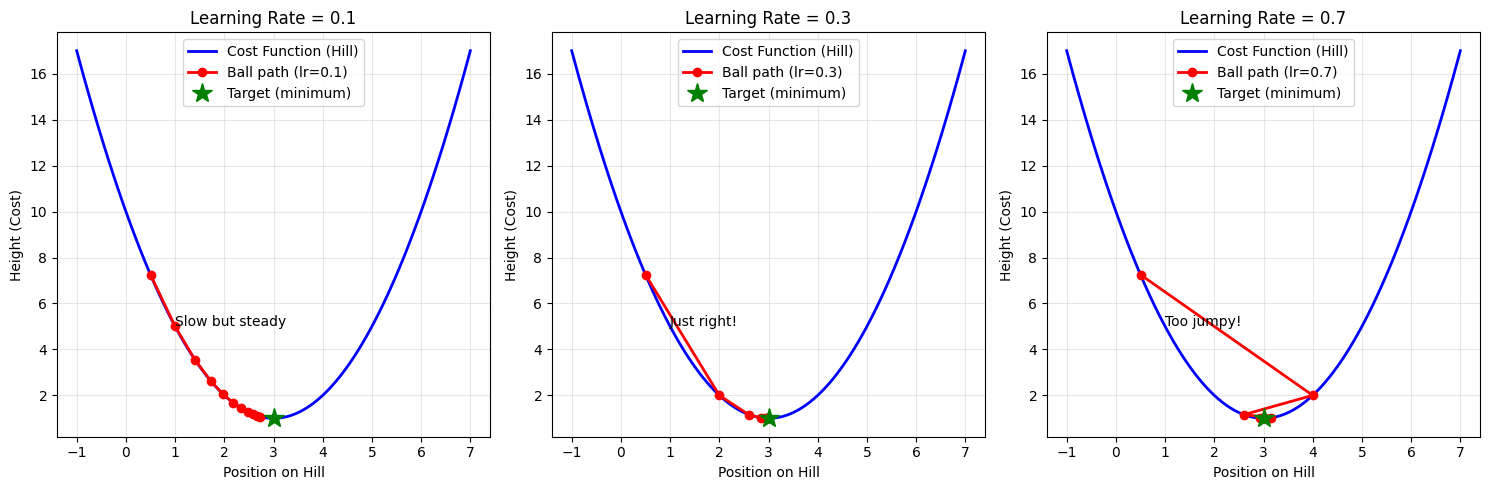


📊 Observations:
• Learning Rate 0.1: Slow but steady convergence
• Learning Rate 0.3: Fast and stable convergence
• Learning Rate 0.7: Oscillates, might overshoot

🎯 When gradient = 0, we've found the minimum!


In [ ]:
# Gradient Descent Visualization
import numpy as np
import matplotlib.pyplot as plt

def gradient_descent_demo():
    print("⚡ Gradient Descent: Rolling Ball Demo")
    print("=" * 40)
    
    # Simple quadratic function: f(x) = (x-3)^2 + 1
    def cost_function(x):
        return (x - 3)**2 + 1
    
    def gradient(x):
        return 2 * (x - 3)  # derivative
    
    # Create the hill (cost function)
    x_range = np.linspace(-1, 7, 100)
    y_range = cost_function(x_range)
    
    # Starting position
    x_start = 0.5
    learning_rates = [0.1, 0.3, 0.7]
    
    plt.figure(figsize=(15, 5))
    
    for i, lr in enumerate(learning_rates):
        plt.subplot(1, 3, i+1)
        
        # Plot the hill
        plt.plot(x_range, y_range, 'b-', linewidth=2, label='Cost Function (Hill)')
        
        # Gradient descent path
        x = x_start
        path_x, path_y = [x], [cost_function(x)]
        
        for step in range(10):
            grad = gradient(x)
            x = x - lr * grad  # Update position
            path_x.append(x)
            path_y.append(cost_function(x))
            
            if abs(grad) < 0.01:  # Converged
                break
        
        # Plot the path
        plt.plot(path_x, path_y, 'ro-', markersize=6, linewidth=2, 
                label=f'Ball path (lr={lr})')
        plt.plot(3, 1, 'g*', markersize=15, label='Target (minimum)')
        
        plt.title(f'Learning Rate = {lr}')
        plt.xlabel('Position on Hill')
        plt.ylabel('Height (Cost)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Add annotations
        if lr == 0.1:
            plt.annotate('Slow but steady', xy=(1, 5), fontsize=10)
        elif lr == 0.3:
            plt.annotate('Just right!', xy=(1, 5), fontsize=10)
        else:
            plt.annotate('Too jumpy!', xy=(1, 5), fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Observations:")
    print("• Learning Rate 0.1: Slow but steady convergence")
    print("• Learning Rate 0.3: Fast and stable convergence")
    print("• Learning Rate 0.7: Oscillates, might overshoot")
    print("\n🎯 When gradient = 0, we've found the minimum!")

gradient_descent_demo()

---
## 7. 📊 Confusion Matrix & Precision

### **Simple Analogy: Medical Test Results**

A doctor tests 100 people for a disease:

```
               ACTUAL CONDITION
            Sick (Positive)  Healthy (Negative)
TEST   Sick    20 (TP)         5 (FP)        ← 25 positive tests
SAYS   Healthy  10 (FN)        65 (TN)       ← 75 negative tests
         ↑              ↑
      30 sick      70 healthy
```

**Precision = TP / (TP + FP) = 20 / (20 + 5) = 80%**

**Meaning:** "When I say someone is sick, I'm right 80% of the time"

In [ ]:
# Interactive Confusion Matrix
def confusion_matrix_demo():
    print("🏥 Medical Test: Confusion Matrix Demo")
    print("=" * 45)
    
    # Example data
    TP = 20  # True Positives: Correctly identified sick patients
    FP = 5   # False Positives: Healthy patients labeled as sick
    FN = 10  # False Negatives: Sick patients labeled as healthy
    TN = 65  # True Negatives: Correctly identified healthy patients
    
    # Calculate metrics
    precision = TP / (TP + FP)
    recall = TP / (TP + FN)
    accuracy = (TP + TN) / (TP + FP + FN + TN)
    f1 = 2 * (precision * recall) / (precision + recall)
    
    # Display confusion matrix
    print("📋 Confusion Matrix:")
    print("                    ACTUAL CONDITION")
    print("                 Sick    Healthy")
    print(f"TEST   Sick      {TP:2d}      {FP:2d}     ← {TP+FP} positive tests")
    print(f"SAYS   Healthy   {FN:2d}      {TN:2d}     ← {FN+TN} negative tests")
    print(f"         ↑        ↑")
    print(f"      {TP+FN:2d} sick   {FP+TN:2d} healthy")
    
    print("\n📊 Calculated Metrics:")
    print(f"🎯 Precision = TP/(TP+FP) = {TP}/({TP}+{FP}) = {precision:.1%}")
    print(f"   → When I say 'sick', I'm right {precision:.1%} of the time")
    
    print(f"\n🎯 Recall = TP/(TP+FN) = {TP}/({TP}+{FN}) = {recall:.1%}")
    print(f"   → I catch {recall:.1%} of all sick patients")
    
    print(f"\n🎯 Accuracy = (TP+TN)/Total = ({TP}+{TN})/100 = {accuracy:.1%}")
    print(f"   → Overall, I'm correct {accuracy:.1%} of the time")
    
    print(f"\n🎯 F1 Score = 2×(Prec×Rec)/(Prec+Rec) = {f1:.1%}")
    print(f"   → Balanced performance score")
    
    print("\n💡 Key Insights:")
    print("• High Precision = Few false alarms")
    print("• High Recall = Don't miss sick patients")
    print("• There's often a trade-off between precision and recall")
    print("• F1 Score balances both for overall assessment")

confusion_matrix_demo()

🏥 Medical Test: Confusion Matrix Demo
📋 Confusion Matrix:
                    ACTUAL CONDITION
                 Sick    Healthy
TEST   Sick      20       5     ← 25 positive tests
SAYS   Healthy   10      65     ← 75 negative tests
         ↑        ↑
      30 sick   70 healthy

📊 Calculated Metrics:
🎯 Precision = TP/(TP+FP) = 20/(20+5) = 80.0%
   → When I say 'sick', I'm right 80.0% of the time

🎯 Recall = TP/(TP+FN) = 20/(20+10) = 66.7%
   → I catch 66.7% of all sick patients

🎯 Accuracy = (TP+TN)/Total = (20+65)/100 = 85.0%
   → Overall, I'm correct 85.0% of the time

🎯 F1 Score = 2×(Prec×Rec)/(Prec+Rec) = 72.7%
   → Balanced performance score

💡 Key Insights:
• High Precision = Few false alarms
• High Recall = Don't miss sick patients
• There's often a trade-off between precision and recall
• F1 Score balances both for overall assessment


---
## 8. 🎲 Cross-Validation - Fair Model Testing

### **Simple Analogy: Testing a Football Team**

You want to know how good your team really is:

**Wrong Way:** Test against the same team you practiced against
- Your team knows their moves
- Gives artificially high performance
- **Overfitting to training data**

**Cross-Validation Way:** Test against 5 different teams
- Game 1: Train with teams B,C,D,E → Test with team A
- Game 2: Train with teams A,C,D,E → Test with team B  
- Game 3: Train with teams A,B,D,E → Test with team C
- And so on...
- **Average performance** gives true ability

In [ ]:
# Cross-Validation Demo
def cross_validation_demo():
    print("⚽ Cross-Validation: Football Team Testing")
    print("=" * 45)
    
    # Simulated team performance against different opponents
    teams = ['Team A', 'Team B', 'Team C', 'Team D', 'Team E']
    
    # Your team's scores against each team (out of 100)
    performances = [85, 78, 92, 73, 88]
    
    print("🏟️ Processo de Validação Cruzada 5-Fold:")
    print("=" * 40)
    
    fold_scores = []
    for i in range(5):
        test_team = teams[i]
        test_score = performances[i]
        
        # Times de treino (todos exceto time de teste)
        train_teams = [teams[j] for j in range(5) if j != i]
        train_scores = [performances[j] for j in range(5) if j != i]
        avg_train_score = sum(train_scores) / len(train_scores)
        
        fold_scores.append(test_score)
        
        print(f"\nFold {i+1}:")
        print(f"  Treinar com: {', '.join(train_teams)}")
        print(f"  Pontuação média de treino: {avg_train_score:.1f}")
        print(f"  Testar contra: {test_team}")
        print(f"  Pontuação de teste: {test_score}")
    
    # Calcular pontuação final de CV
    cv_score = sum(fold_scores) / len(fold_scores)
    cv_std = np.std(fold_scores)
    
    print("\n🏆 Resultados da Validação Cruzada:")
    print(f"Pontuações individuais dos folds: {fold_scores}")
    print(f"Pontuação média de CV: {cv_score:.1f} ± {cv_std:.1f}")
    print(f"Melhor desempenho: {max(fold_scores)}")
    print(f"Pior desempenho: {min(fold_scores)}")
    
    print("\n💡 Why Cross-Validation is Important:")
    print("• Tests model against multiple 'unseen' datasets")
    print("• Gives more reliable performance estimate")
    print("• Helps detect if model works consistently")
    print("• Essential for hyperparameter tuning")
    
    # Hyperparameter tuning example
    print("\n⚙️ Hyperparameter Tuning Example:")
    formations = ['4-4-2', '4-3-3', '3-5-2']
    formation_scores = {
        '4-4-2': [82, 79, 85, 77, 80],
        '4-3-3': [85, 78, 92, 73, 88], 
        '3-5-2': [78, 75, 88, 70, 84]
    }
    
    for formation, scores in formation_scores.items():
        avg_score = sum(scores) / len(scores)
        print(f"{formation}: Average CV score = {avg_score:.1f}")
    
    best_formation = max(formation_scores.items(), key=lambda x: sum(x[1])/len(x[1]))
    print(f"\n🏆 Best formation: {best_formation[0]}")

cross_validation_demo()

⚽ Cross-Validation: Football Team Testing
🏟️ 5-Fold Cross-Validation Process:

Fold 1:
  Train with: Team B, Team C, Team D, Team E
  Average training score: 82.8
  Test against: Team A
  Test score: 85

Fold 2:
  Train with: Team A, Team C, Team D, Team E
  Average training score: 84.5
  Test against: Team B
  Test score: 78

Fold 3:
  Train with: Team A, Team B, Team D, Team E
  Average training score: 81.0
  Test against: Team C
  Test score: 92

Fold 4:
  Train with: Team A, Team B, Team C, Team E
  Average training score: 85.8
  Test against: Team D
  Test score: 73

Fold 5:
  Train with: Team A, Team B, Team C, Team D
  Average training score: 82.0
  Test against: Team E
  Test score: 88

🏆 Cross-Validation Results:
Individual fold scores: [85, 78, 92, 73, 88]
Average CV score: 83.2 ± 6.9
Best performance: 92
Worst performance: 73

💡 Why Cross-Validation is Important:
• Tests model against multiple 'unseen' datasets
• Gives more reliable performance estimate
• Helps detect if mod

---
## 🎯 Resumo: Conceitos Principais para Sucesso na Prova

### **🔥 Conceitos Mais Importantes:**

1. **Vetores de Suporte (SVM):** Pontos que definem o limite de decisão
2. **Pontuação F1:** Média harmônica de precisão e revocação  
3. **Limiar de Regressão Logística:** 0.5 padrão para classificação binária
4. **Regressão Ridge:** Encolhe coeficientes para prevenir overfitting
5. **kNN com k Baixo:** Causa overfitting (muito sensível)
6. **Descida do Gradiente:** Gradiente zero = mínimo encontrado
7. **Precisão:** VP/(VP+FP) = "Quão precisas são as predições positivas?"
8. **Validação Cruzada:** Para avaliação justa de modelo e ajuste de hiperparâmetros

### **🎲 Truques Rápidos de Memória:**

- **SVM:** Suporte = "Sustenta o limite de decisão"
- **F1:** "F"az "1" amizade com precisão e revocação
- **Ridge:** "Ridge" = crista de montanha = suave, controlado
- **k baixo:** "k=1" = perguntar a 1 amigo = não confiável
- **Precisão:** Predições positivas "precisas"
- **Validação Cruzada:** Cruzada = múltiplos testes = avaliação justa

### **⚠️ Erros Comuns a Evitar:**

1. ❌ Confundir precisão com revocação
2. ❌ Pensar que Ridge elimina características (isso é Lasso)
3. ❌ Acreditar que k alto no kNN é sempre melhor
4. ❌ Usar conjunto de teste para seleção de modelo
5. ❌ Esquecer que regressão logística produz probabilidades

---
**🎓 Você está pronto para a prova! Pratique esses conceitos e você irá muito bem!** 🚀